# WP4 Annex A: period prior models, sediment-hosted branch

Builds realizations of the Stuart Shelf around Olympic Dam from Annex A Sections 2, 3 and 5, using only the 1975-05-02 information state.

- **Section 2 rules:** realizations are generated unconditionally and weighted later, so no gravity or magnetics is read here; one parameter, one row.
- **Section 3 levels:** frame, basalt, redox, ore, properties, built in that order.
- **Section 5 table:** every number the sampler uses is checked against its confirmed row.

Step 0 shows the priors, Steps 1 to 5 build seeds 11, 23 and 37 level by level, Step 6 checks an ensemble of 50, Step 7 shows the three models in 3D. Steps 8 to 13 are the Section 4 prior predictive check, Step 14 the Section 6 documentary basis, Steps 15 to 18 the Section 7 outputs (run locally).

Steps 0 to 14 run in about 1.5 minutes, Section 7 about 5 more; needs `simpeg`, `discretize`, `pyproj` and `netCDF4`.

**This copy runs from the `SVOI_OD` folder** (open it with this folder as the working directory). Inputs are read from `01_citation_table/`, `03_sampler_inputs/` and `04_prior_predictive_observed/`; figures and tables are written to `08_prior_models/`. It is generated from `02_code/notebooks/wp4_period_prior_sediment_hosted.ipynb` by the folder builder; edit that one.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

Read from this folder: the citation table, O'Driscoll's 1974 targets and the regional window. `04_prior_predictive_observed/` is not opened. `cited(row, ...)` stops the run if a number is not in its confirmed row.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy import ndimage, stats
from pyproj import Transformer
import discretize

PM = Path(".")                                               # this notebook sits in the SVOI_OD folder
FIG = Path("08_prior_models/figures")
TAB = Path("08_prior_models")
assert (PM / "01_citation_table").is_dir(), "run from the SVOI_OD folder"
FIG.mkdir(parents=True, exist_ok=True)

CT = pd.read_csv(PM / "01_citation_table/wp4_annexA_citation_table_draft.csv").set_index("row_id")
TG = pd.read_csv(PM / "03_sampler_inputs/wp4_prior_lineament_targets_1974.csv")
WIN = pd.read_csv(PM / "03_sampler_inputs/study_windows.csv").set_index("window").loc["regional"]
ANNEX_GREY = "#e3e3e3"                                  # shading for a confirmed or stated range
OD_LON, OD_LAT = 136.887, -30.441                      # Olympic Dam, for orientation only; never used by the sampler

def cited(row, *numbers):
    """assert that every number the code uses for a row is written in that row's confirmed distribution"""
    txt = CT.loc[row, "proposed_distribution"].replace(",", "")
    written = {float(x) for x in re.findall(r"\d+\.?\d*", txt)}
    for v in numbers:
        assert float(v) in written, (row, v, txt)
    assert str(CT.loc[row, "confirmed"]).startswith("confirmed") or "confirmed" in str(CT.loc[row, "confirmed"]), row
    return True

print(f"citation table: {len(CT)} rows, all confirmed: {bool(CT.confirmed.str.contains('confirmed').all())}")
print(CT[["parameter", "status"]].to_string())
print(f"\nO'Driscoll 1974 targets: {len(TG)}, in the regional window: {int(TG.in_regional_window.sum())}")


citation table: 15 rows, all confirmed: True
                                             parameter                                  status
row_id                                                                                        
L1-1                 Cover unit thicknesses (per unit)  translated; cover upper bound declared
L1-2         Between-bore thickness variance and trend                     declared assumption
L1-3                      Basement unconformity relief                              translated
L2-1    Basalt object intensity (count per 10,000 km2)                     declared assumption
L2-2                  Basalt lateral extent; thickness                                   cited
L2-3                    Lineament intensity multiplier                              translated
L3-1              P(reduced facies present at contact)                                   cited
L3-2             Reduced-facies belt and patch lengths                                   cited
L4-1 

## The sampler

`realize(seed)` builds one realization on a 1 km mesh in MGA zone 53 (80 layers of 25 m to 2 km, plus padding).

- **Level 1:** cover above the Pandurra (L1-1) as a trend plus random field (L1-2), split into units by fixed fractions; Pandurra 200 to 638 m (L1-1); basement relief (L1-3).
- **Level 2:** basalt objects as a Poisson process (L2-1), boosted inside the 1974 circles (L2-3) and renormalized; each an ellipse of drawn extent and thickness (L2-2) on the basement surface.
- **Level 3:** reduced facies at the contact, a thresholded anisotropic field (L3-1, L3-2).
- **Level 4:** margin zone within d of a basalt edge and on a reduced belt (L4-1); ore disks cover fraction P of it (L4-2), boosted in the circles (L4-3); tonnage derived from diameter, thickness and grade (L4-4).
- **Level 5:** density, susceptibility and resistivity by unit (L5-1, L5-2); ore density increment from grade (L5-3).

Fixed settings are listed in the folder README (basement properties, basalt and basement resistivity, basalt and belt shapes, chalcopyrite constants). Sampler choices: trend amplitude equal to the 20% residual sd, uniform trend azimuth, cover floored at 50 m, reach d at least half a cell.


In [3]:
# ---- mesh: regional window in GDA94 / MGA zone 53, 1 km cells, 25 m layers to 2 km then padding -----------------
to_mga = Transformer.from_crs("EPSG:4326", "EPSG:28353", always_xy=True)
xs, ys = to_mga.transform([WIN.lon_min, WIN.lon_max, WIN.lon_min, WIN.lon_max], [WIN.lat_min, WIN.lat_min, WIN.lat_max, WIN.lat_max])
X0, X1, Y0, Y1 = np.floor(min(xs) / 1e3) * 1e3, np.ceil(max(xs) / 1e3) * 1e3, np.floor(min(ys) / 1e3) * 1e3, np.ceil(max(ys) / 1e3) * 1e3
DX = 1000.0
NX, NY = int((X1 - X0) / DX), int((Y1 - Y0) / DX)
HZ = [25.0] * 80 + [25.0 * 1.5 ** k for k in range(1, 7)]
MESH = discretize.TensorMesh([[DX] * NX, [DX] * NY, HZ[::-1]], origin=[X0, Y0, -sum(HZ)])
ZC = -MESH.cell_centers_z[::-1]                        # cell-centre depths below surface (m), top layer first
XC = X0 + DX * (np.arange(NX) + 0.5); YC = Y0 + DX * (np.arange(NY) + 0.5)
GX, GY = np.meshgrid(XC, YC)                           # (NY, NX) map grid
AREA_KM2 = NX * NY * (DX / 1e3) ** 2
TX, TYY = to_mga.transform(TG.lon.values, TG.lat.values)
IN_CIRCLE = np.zeros((NY, NX), bool)
for x, y, r in zip(TX, TYY, TG.radius_km.values):
    IN_CIRCLE |= (GX - x) ** 2 + (GY - y) ** 2 <= (r * 1e3) ** 2
ODX, ODY = to_mga.transform(OD_LON, OD_LAT)

# ---- fixed settings (held constant, not sampled; README of annexA_prior_model) --------------------------------------
FIX = dict(rho_basement=2.60, k_basement=500.0, res_basalt=3100.0, res_basement=5000.0,
           basalt_aspect=4.7 / 3.6, basalt_az=157.0,          # Roopena outcrop, PORT AUGUSTA 1968
           belt_aspect=32.0 / 10.0, belt_az=10.0,              # Mount Gunson corridor, Johns 1972 (RB 72/00189)
           cu_in_ccp=0.346, rho_ccp=4.2)                       # chalcopyrite, Parasnis 1973 Table V
LITH = {1: "Andamooka Limestone", 2: "Arcoona Quartzite", 3: "unnamed siltstones", 4: "Woomera Shale",
        5: "Pandurra Formation", 6: "basalt", 7: "basement"}

# ---- the draws, each tied to its citation row -------------------------------------------------------------------------
cited("L1-1", 120, 600, 0, 0.15, 0.24, 0.23, 0.53, 200, 638)
cited("L1-2", 20, 10, 50); cited("L1-3", 0, 150); cited("L2-1", 2, 10); cited("L2-2", 2, 20, 75, 300)
cited("L2-3", 1, 18); cited("L3-1", 0.05, 0.30); cited("L3-2", 30, 150, 0.5, 5); cited("L4-1", 0, 15)
cited("L4-2", 0.09, 0.35); cited("L4-3", 1, 5); cited("L4-4", 1, 15, 1.0, 4.5)
cited("L5-1", 2.80, 0.12, 2.60, 3.35, 250, 105000); cited("L5-2", 2.60, 2.70, 2.10, 2.20, 2.44, 0.05, 10, 100, 1, 1000)
U = lambda r, a, b: r.uniform(a, b)
LU = lambda r, a, b: float(np.exp(r.uniform(np.log(a), np.log(b))))

def draw(r):
    """one set of realization-level parameters; row ids in the keys"""
    return {"L1-1 cover_total_m": U(r, 120, 600), "L1-1 limestone_share": U(r, 0, 0.15), "L1-1 pandurra_m": U(r, 200, 638),
            "L1-2 corr_length_km": LU(r, 10, 50), "L1-3 relief_m": U(r, 0, 150),
            "L2-1 intensity_per_1e4km2": U(r, 2, 10), "L2-3 basalt_multiplier": U(r, 1, 18),
            "L3-1 p_reduced": U(r, 0.05, 0.30), "L3-2 belt_length_km": LU(r, 30, 150),
            "L4-1 reach_d_km": U(r, 0, 15), "L4-2 p_ore": U(r, 0.09, 0.35), "L4-3 ore_multiplier": U(r, 1, 5),
            "L5-2 rho_quartzite": U(r, 2.60, 2.70), "L5-2 rho_shale": U(r, 2.10, 2.60), "L5-2 rho_limestone": U(r, 2.20, 2.70),
            "L5-2 rho_pandurra": r.normal(2.44, 0.05), "L5-2 k_cover": LU(r, 10, 100), "L5-2 res_cover": LU(r, 1, 1000)}

def grf(r, lx_km, ly_km=None, az=0.0, pad=2):
    """zero-mean unit-variance Gaussian random field on the map grid; correlation lengths along az and across it"""
    ly_km = lx_km if ly_km is None else ly_km
    ny, nx = NY * pad, NX * pad
    kx = np.fft.fftfreq(nx, d=DX / 1e3) * 2 * np.pi; ky = np.fft.fftfreq(ny, d=DX / 1e3) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky); a = np.radians(az)
    kpar = KX * np.sin(a) + KY * np.cos(a); kper = KX * np.cos(a) - KY * np.sin(a)
    amp = np.exp(-((kpar * lx_km) ** 2 + (kper * ly_km) ** 2) / 8.0)
    f = np.real(np.fft.ifft2(np.fft.fft2(r.standard_normal((ny, nx))) * amp))[:NY, :NX]
    return (f - f.mean()) / f.std()

def ellipse(x0, y0, length_km, aspect, az):
    a = np.radians(az); dx, dy = (GX - x0) / 1e3, (GY - y0) / 1e3
    u = dx * np.sin(a) + dy * np.cos(a); v = dx * np.cos(a) - dy * np.sin(a)
    return (u / (length_km / 2)) ** 2 + (v / (length_km / 2 / aspect)) ** 2 <= 1.0

def weighted_points(r, n, weight, mask=None):
    """n random map points with probability proportional to weight (optionally inside mask); jittered inside cells"""
    w = weight.astype(float) * (1 if mask is None else mask)
    if n == 0 or w.sum() == 0: return np.empty(0), np.empty(0)
    idx = r.choice(w.size, size=n, p=(w / w.sum()).ravel())
    iy, ix = np.unravel_index(idx, w.shape)
    return XC[ix] + r.uniform(-DX / 2, DX / 2, n), YC[iy] + r.uniform(-DX / 2, DX / 2, n)

# ---- the five levels as stages; a branch is data that names its draw, stages, properties and summary (Section 7) ----------
def level1_frame(r, p, F):
    T0, lc = p["L1-1 cover_total_m"], p["L1-2 corr_length_km"]
    g = np.radians(r.uniform(0, 360))
    trend = ((GX - GX.mean()) * np.sin(g) + (GY - GY.mean()) * np.cos(g)) / (NX * DX / 2)
    cover = np.clip(T0 * (1 + 0.20 * grf(r, lc) + 0.20 * trend), 50, None)
    fl = p["L1-1 limestone_share"]
    s1 = cover * fl; s2 = s1 + cover * (1 - fl) * 0.24; s3 = s2 + cover * (1 - fl) * 0.23; s4 = cover
    rel = grf(r, lc); rel = p["L1-3 relief_m"] * ((rel - rel.min()) / (rel.max() - rel.min()) - 0.5)
    return dict(cover=cover, s1=s1, s2=s2, s3=s3, s4=s4, base=s4 + p["L1-1 pandurra_m"] + rel)   # base = top of basement

def level2_basalt(r, p, F):
    lam, M2, fin = p["L2-1 intensity_per_1e4km2"], p["L2-3 basalt_multiplier"], IN_CIRCLE.mean()
    n_obj = r.poisson(lam * AREA_KM2 / 1e4)
    bx, by = weighted_points(r, n_obj, np.where(IN_CIRCLE, M2, 1.0) / (fin * M2 + (1 - fin)))
    btop = np.full((NY, NX), np.nan); bid = np.zeros((NY, NX), int); objs = []
    for j, (x, y) in enumerate(zip(bx, by), 1):
        L = LU(r, 2, 20); t = LU(r, 75, 300)
        rho = stats.truncnorm.rvs((2.60 - 2.80) / 0.12, (3.35 - 2.80) / 0.12, loc=2.80, scale=0.12, random_state=r)
        k = LU(r, 250, 105000)
        m = ellipse(x, y, L, FIX["basalt_aspect"], FIX["basalt_az"])
        btop = np.where(m, np.maximum(F["base"] - t, F["s4"]), btop); bid[m] = j
        objs.append(dict(obj=j, x=x, y=y, length_km=L, thickness_m=t, rho=rho, k=k,
                         in_circle=bool(IN_CIRCLE[np.argmin(abs(YC - y)), np.argmin(abs(XC - x))])))
    basalt = bid > 0
    return dict(btop=btop, bid=bid, basalt=basalt, objs=objs, contact=np.where(basalt, btop, F["base"]))

def level3_redox(r, p, F):
    Lb = p["L3-2 belt_length_km"]
    red = grf(r, Lb / 3.0, Lb / 3.0 / FIX["belt_aspect"], FIX["belt_az"])
    return dict(reduced=red >= np.quantile(red, 1 - p["L3-1 p_reduced"]))

def level4_ore(r, p, F):
    d, basalt = p["L4-1 reach_d_km"], F["basalt"]
    if basalt.any():
        dist = np.where(basalt, ndimage.distance_transform_edt(basalt), ndimage.distance_transform_edt(~basalt)) * DX / 1e3
        zone = (dist <= max(d, 0.5)) & F["reduced"]
    else:
        zone = np.zeros_like(F["reduced"])
    M4, P = p["L4-3 ore_multiplier"], p["L4-2 p_ore"]
    Dg = np.exp(np.linspace(np.log(0.5), np.log(5), 2001)); mean_area = np.mean(np.pi * Dg ** 2 / 4)
    n_ore = r.poisson(P * zone.sum() * (DX / 1e3) ** 2 / mean_area) if zone.any() else 0
    fz = (zone & IN_CIRCLE).sum() / max(zone.sum(), 1)
    ox, oy = weighted_points(r, n_ore, np.where(IN_CIRCLE, M4, 1.0) / (fz * M4 + (1 - fz)), zone)
    ores = []
    for x, y in zip(ox, oy):
        Dk = LU(r, 0.5, 5); th = LU(r, 1, 15); gr = U(r, 1.0, 4.5)
        host = p["L5-2 rho_pandurra"]
        vf = gr / 100 / FIX["cu_in_ccp"] * host / FIX["rho_ccp"]; drho = vf * (FIX["rho_ccp"] - host)
        ix, iy = np.argmin(abs(XC - x)), np.argmin(abs(YC - y))
        ores.append(dict(x=x, y=y, diam_km=Dk, thick_m=th, grade=gr, drho=drho, depth_m=F["contact"][iy, ix],
                         Mt=np.pi * Dk ** 2 / 4 * 1e6 * th * (host + drho) / 1e6, in_circle=bool(IN_CIRCLE[iy, ix])))
    return dict(zone=zone, ores=ores)

def level5_properties(p, F):
    z = ZC[None, None, :]
    lith = np.full((NY, NX, len(ZC)), 7, np.int8)
    for code, surf in [(1, F["s1"]), (2, F["s2"]), (3, F["s3"]), (4, F["s4"]), (5, F["base"])]:
        lith[(lith == 7) & (z < surf[:, :, None])] = code
    lith[(z >= F["btop"][:, :, None]) & (z < F["base"][:, :, None]) & F["basalt"][:, :, None]] = 6
    rho_u = {1: p["L5-2 rho_limestone"], 2: p["L5-2 rho_quartzite"], 3: p["L5-2 rho_shale"], 4: p["L5-2 rho_shale"],
             5: p["L5-2 rho_pandurra"], 7: FIX["rho_basement"]}
    rho3 = np.vectorize(lambda c: rho_u.get(c, np.nan))(lith).astype(np.float32)
    k3 = np.where(lith <= 5, p["L5-2 k_cover"], FIX["k_basement"]).astype(np.float32)
    res3 = np.where(lith <= 5, p["L5-2 res_cover"], FIX["res_basement"]).astype(np.float32)
    for o in F["objs"]:
        m3 = (lith == 6) & (F["bid"][:, :, None] == o["obj"])
        rho3[m3], k3[m3] = o["rho"], o["k"]
    res3[lith == 6] = FIX["res_basalt"]
    return dict(lith=lith, rho=rho3, k=k3, res=res3)

def sh_summary(p, F):
    objs, ores = F["objs"], F["ores"]
    return dict(n_basalt=len(objs), basalt_frac=F["basalt"].mean(), reduced_frac=F["reduced"].mean(),
                zone_km2=F["zone"].sum() * (DX / 1e3) ** 2, n_ore=len(ores), Mt_total=sum(o["Mt"] for o in ores),
                contrast=np.mean([o["rho"] for o in objs]) - p["L5-2 rho_pandurra"] if objs else np.nan)

BRANCH_SH = dict(name="sediment-hosted Cu, Annex A", citation_table="01_citation_table/wp4_annexA_citation_table_draft.csv",
                 geometry_family="flat-lying cover stack; flow-pile ellipses on the basement surface",
                 mineralization_rule="ore disks in the margin zone: within d of a basalt edge and on a reduced belt",
                 draw=draw, stages=[level1_frame, level2_basalt, level3_redox, level4_ore],
                 properties=level5_properties, summary=sh_summary)

def realize_branch(branch, seed, keep_volume=False):
    """one realization of any branch: draw, run the stages in order, attach properties; seed -> numpy default_rng(seed)"""
    r = np.random.default_rng(seed); p = branch["draw"](r); F = {}
    for stage in branch["stages"]:
        F.update(stage(r, p, F))
    out = {"seed": seed, **p, **branch["summary"](p, F)}
    if keep_volume:
        F.update(branch["properties"](p, F))
    maps = {k: v for k, v in F.items() if k not in ("objs", "ores", "basalt", "s4")}
    return out, maps, pd.DataFrame(F["objs"]), pd.DataFrame(F["ores"])

def realize(seed, keep_volume=False):
    return realize_branch(BRANCH_SH, seed, keep_volume)

print(f"mesh: {NX} x {NY} x {len(ZC)} = {MESH.n_cells:,} cells; window {AREA_KM2:,.0f} km2; "
      f"target circles cover {IN_CIRCLE.mean()*100:.1f}% of it")
print("fixed settings:", {k: round(v, 3) for k, v in FIX.items()})
print(f"grid: origin E {X0:,.0f} m, N {Y0:,.0f} m (GDA94 / MGA zone 53), {NX} x {NY} cells of {DX:.0f} m; "
      f"{len(HZ)} layers: 80 x 25 m to 2,000 m, then {', '.join(f'{v:.0f}' for v in HZ[80:])} m to {sum(HZ):,.0f} m")


mesh: 113 x 120 x 86 = 1,166,160 cells; window 13,560 km2; target circles cover 6.6% of it
fixed settings: {'rho_basement': 2.6, 'k_basement': 500.0, 'res_basalt': 3100.0, 'res_basement': 5000.0, 'basalt_aspect': 1.306, 'basalt_az': 157.0, 'belt_aspect': 3.2, 'belt_az': 10.0, 'cu_in_ccp': 0.346, 'rho_ccp': 4.2}
grid: origin E 624,000 m, N 6,570,000 m (GDA94 / MGA zone 53), 113 x 120 cells of 1000 m; 86 layers: 80 x 25 m to 2,000 m, then 38, 56, 84, 127, 190, 285 m to 2,779 m


### Reading the output

113 x 120 x 86 cells over 13,560 km2; the 1974 circles cover 6.6% of it. All 14 `cited` checks pass.


### The prior model grid

| | |
|---|---|
| Coordinates | GDA94 / MGA zone 53 (EPSG:28353), metres; the regional window (136.30 to 137.45 E, 30.98 to 29.92 S) rounded out to whole kilometres |
| Extent | E 624,000 to 737,000 m, N 6,570,000 to 6,690,000 m: 113 x 120 km, 13,560 km2 |
| Horizontal cells | 1,000 m, uniform, 113 x 120 |
| Vertical cells | 80 layers of 25 m from the surface to 2,000 m, then 6 padding layers growing by 1.5 (38, 56, 84, 127, 190, 285 m) to 2,779 m |
| Total | 113 x 120 x 86 = 1,166,160 cells (`discretize.TensorMesh`, flat surface at z = 0) |

Why this spacing. 1 km is below the spacing of the t0 data the prior is weighted against: gravity stations about 5.3 km apart (median nearest neighbour; 3.7 to 6.2 km), magnetic lines 1.6 km apart. 25 m resolves every cover unit and the thinnest basalt pile (75 m, three layers); 2,000 m covers the deepest basement in the prior (about 1,500 m).

What the grid does not resolve. Basalt outlines are rasterized to 1 km cells, so the smallest objects (2 km) are a few cells. The ore blanket (1 to 15 m thick, 0.5 to 5 km across) is thinner than a layer: it is carried as disk objects with position, size, depth, grade and density increment, not as voxels, and it is not in the property volumes, so the forward models omit it (an infinite slab of the thickest, richest blanket gives under 0.1 mGal). Local refinement (Step 17) regenerates any realization on a 250 m grid.

Forward modelling (Section 4) uses the same cells, padded by reflection to 256 x 256 for the FFT; gravity is computed at the surface and magnetics at the 150 m survey clearance.


### Step 0. Prior distributions


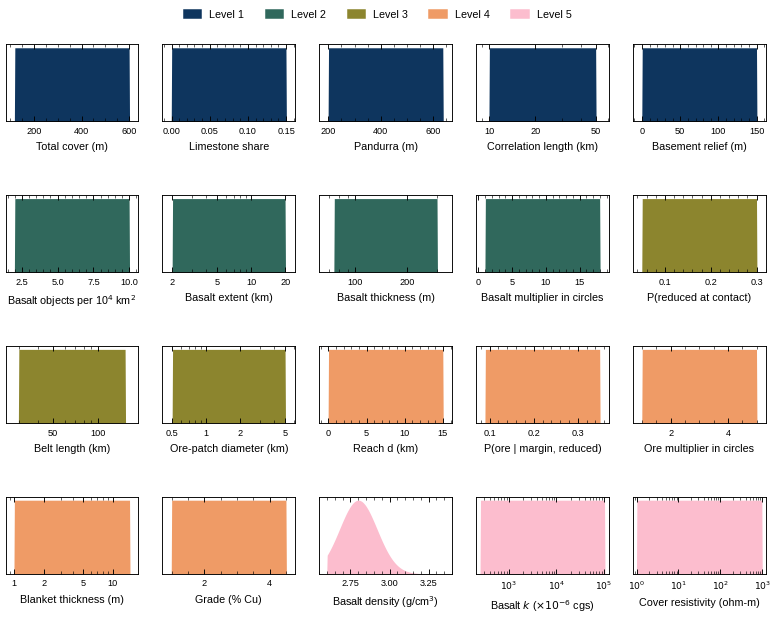

20 sampled quantities from 15 citation rows; each panel is checked against its row by cited()


In [4]:
PANELS = [("L1-1", "Total cover (m)", ("u", 120, 600)), ("L1-1", "Limestone share", ("u", 0, 0.15)),
          ("L1-1", "Pandurra (m)", ("u", 200, 638)), ("L1-2", "Correlation length (km)", ("lu", 10, 50)),
          ("L1-3", "Basement relief (m)", ("u", 0, 150)), ("L2-1", "Basalt objects per 10$^4$ km$^2$", ("u", 2, 10)),
          ("L2-2", "Basalt extent (km)", ("lu", 2, 20)), ("L2-2", "Basalt thickness (m)", ("lu", 75, 300)),
          ("L2-3", "Basalt multiplier in circles", ("u", 1, 18)), ("L3-1", "P(reduced at contact)", ("u", 0.05, 0.30)),
          ("L3-2", "Belt length (km)", ("lu", 30, 150)), ("L3-2", "Ore-patch diameter (km)", ("lu", 0.5, 5)),
          ("L4-1", "Reach d (km)", ("u", 0, 15)), ("L4-2", "P(ore | margin, reduced)", ("u", 0.09, 0.35)),
          ("L4-3", "Ore multiplier in circles", ("u", 1, 5)), ("L4-4", "Blanket thickness (m)", ("lu", 1, 15)),
          ("L4-4", "Grade (% Cu)", ("u", 1.0, 4.5)), ("L5-1", "Basalt density (g/cm$^3$)", ("tn", 2.80, 0.12, 2.60, 3.35)),
          ("L5-1", "Basalt $k$ ($\\times10^{-6}$ cgs)", ("lu", 250, 105000)), ("L5-2", "Cover resistivity (ohm-m)", ("lu", 1, 1000))]
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}   # batlow, as in the other figures
fig, axes = plt.subplots(4, 5, figsize=(COL2, 5.6))
fig.subplots_adjust(left=0.03, right=0.99, top=0.93, bottom=0.07, wspace=0.18, hspace=0.95)
for ax, (row, lab, dist) in zip(axes.flat, PANELS):
    c = LEVEL_COL[int(row[1])]
    if dist[0] == "u":
        a, b = dist[1], dist[2]; x = np.linspace(a - 0.08 * (b - a), b + 0.08 * (b - a), 300)
        y = ((x >= a) & (x <= b)) / (b - a); ax.fill_between(x, y, color=c, lw=0); ax.set_xlim(x[0], x[-1])
    elif dist[0] == "lu":
        a, b = dist[1], dist[2]; x = np.exp(np.linspace(np.log(a) - 0.2, np.log(b) + 0.2, 300))
        y = ((x >= a) & (x <= b)) / np.log(b / a); ax.fill_between(x, y, color=c, lw=0)
        ax.set_xscale("log"); ax.set_xlim(x[0], x[-1])
        if b / a > 200:
            tk = [10.0 ** n for n in range(-2, 7) if a <= 10.0 ** n <= b]; tl = [f"$10^{{{int(np.log10(v))}}}$" for v in tk]
        else:
            tk = [v for v in (0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500) if a <= v <= b]; tl = [f"{v:g}" for v in tk]
        ax.set_xticks(tk); ax.set_xticklabels(tl); ax.xaxis.set_minor_formatter(plt.NullFormatter())
    else:
        m, s, a, b = dist[1:]; x = np.linspace(a - 0.05, b + 0.05, 300)
        y = stats.truncnorm.pdf(x, (a - m) / s, (b - m) / s, loc=m, scale=s); ax.fill_between(x, y, color=c, lw=0)
        ax.set_xlim(x[0], x[-1])
    ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(0, None)
    ax.set_xlabel(f"{lab}", fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
h = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"Level {k}") for k, c in LEVEL_COL.items()]
fig.legend(handles=h, loc="upper center", ncol=5, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0))
fig.savefig(FIG / "wp4_PP_00_prior_distributions.png", dpi=300)
plt.show()
print(f"{len(PANELS)} sampled quantities from {CT.shape[0]} citation rows; each panel is checked against its row by cited()")


### How to read this figure

One panel per sampled quantity, coloured by level (batlow, as in the other figures). Flat blocks are uniform on a linear axis or log-uniform on a log axis; basalt density is the only shaped prior (normal 2.80, sd 0.12, truncated 2.60 to 3.35).


### Step 1. Level 1, stratigraphic frame (seed 11)


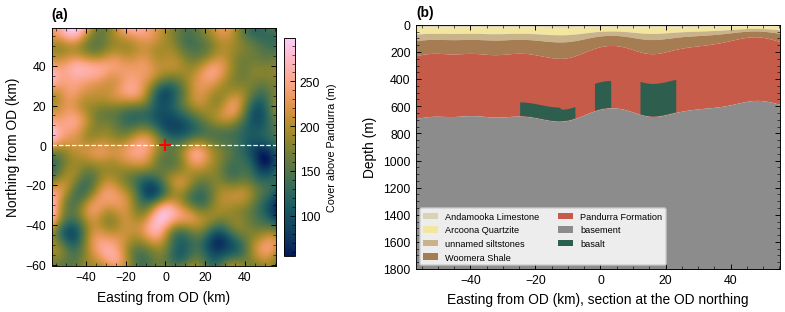

realization 11: total cover drawn 182 m (field 55-299 m), limestone share 0.075, Pandurra 463 m, relief 22 m, correlation length 10.5 km
depth to the top of basement 521-763 m


In [5]:
OUT, MAPS, OBJ, ORE = {}, {}, {}, {}
for s in (11, 23, 37):
    OUT[s], MAPS[s], OBJ[s], ORE[s] = realize(s, keep_volume=True)
S = 11; m = MAPS[S]; o = OUT[S]
iy = int(np.argmin(abs(YC - ODY)))                            # the west-east section passes the deposit's northing
ext = [(X0 - ODX) / 1e3, (X1 - ODX) / 1e3, (Y0 - ODY) / 1e3, (Y1 - ODY) / 1e3]
xkm = (XC - ODX) / 1e3
fig, axes = plt.subplots(1, 2, figsize=(COL2, 3.0), gridspec_kw={"width_ratios": [1, 1.5]})
fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.14, wspace=0.40)
ax = axes[0]
im = ax.imshow(m["cover"], origin="lower", extent=ext, cmap=BATLOW, aspect="equal")
ax.axhline(0, color="white", lw=0.8, ls="--")
ax.plot(0, 0, "+", color="red", ms=8, mew=1.4)
ax.set_xlabel("Easting from OD (km)"); ax.set_ylabel("Northing from OD (km)")
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03); cb.set_label("Cover above Pandurra (m)", fontsize=FS_ANNOT)
ax = axes[1]
UNIT_COL = {1: "#d9d2b5", 2: "#f2e6a0", 3: "#c9b38a", 4: "#a67c52", 5: "#c75b4a", 6: "#2e5e4e", 7: "#8c8c8c"}
tops = [np.zeros(NX), m["s1"][iy], m["s2"][iy], m["s3"][iy], m["cover"][iy], m["base"][iy]]
for code in range(1, 6):
    ax.fill_between(xkm, tops[code - 1], tops[code], color=UNIT_COL[code], lw=0, label=LITH[code])
ax.fill_between(xkm, m["base"][iy], 2000, color=UNIT_COL[7], lw=0, label=LITH[7])
bs = ~np.isnan(m["btop"][iy])
ax.fill_between(xkm, np.where(bs, m["btop"][iy], m["base"][iy]), m["base"][iy], where=bs, color=UNIT_COL[6], lw=0, label=LITH[6])
ax.invert_yaxis(); ax.set_ylim(1800, 0); ax.set_xlim(xkm[0], xkm[-1])
ax.set_xlabel("Easting from OD (km), section at the OD northing"); ax.set_ylabel("Depth (m)")
ax.legend(fontsize=FS_ANNOT - 1, loc="lower left", ncol=2, framealpha=0.85, frameon=True)
panel_labels(axes, ("(a)", "(b)"))
fig.savefig(FIG / "wp4_PP_01_level1_frame.png", dpi=300)
plt.show()
print(f"realization {S}: total cover drawn {o['L1-1 cover_total_m']:.0f} m (field {m['cover'].min():.0f}-{m['cover'].max():.0f} m), "
      f"limestone share {o['L1-1 limestone_share']:.3f}, Pandurra {o['L1-1 pandurra_m']:.0f} m, "
      f"relief {o['L1-3 relief_m']:.0f} m, correlation length {o['L1-2 corr_length_km']:.1f} km")
print(f"depth to the top of basement {m['base'].min():.0f}-{m['base'].max():.0f} m")


### How to read this figure

(a) Cover above the Pandurra, 55 to 299 m around a drawn mean of 182 m; dashed line is the section. (b) West to east section through the Olympic Dam northing: Pandurra 463 m, relief 22 m, basement at 521 to 763 m. Dark green bodies are Level 2 basalt.


### Step 2. Level 2, basalt objects


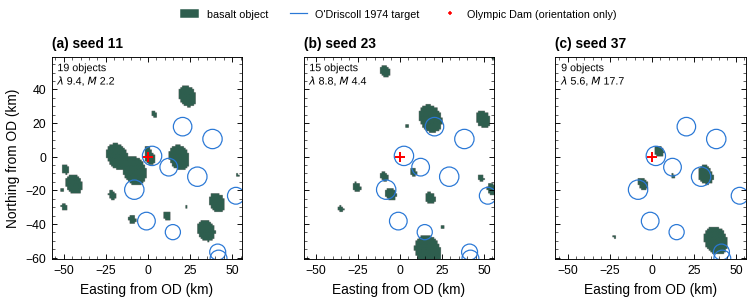

seed 11: 19 objects, 2 centred in a circle; extent 2.1-18.0 km, thickness 76-285 m, basalt covers 7.5% of the window
seed 23: 15 objects, 2 centred in a circle; extent 2.3-19.8 km, thickness 78-297 m, basalt covers 4.9% of the window
seed 37: 9 objects, 7 centred in a circle; extent 2.1-17.5 km, thickness 86-197 m, basalt covers 2.5% of the window


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (11, 23, 37)):
    m = MAPS[s]
    ax.imshow(np.where(m["bid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#2e5e4e"]), aspect="equal")
    for x, y, rr in zip(TX, TYY, TG.radius_km.values):
        ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec="#2a78d6", lw=0.8))
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"{o['n_basalt']} objects\n$\\lambda$ {o['L2-1 intensity_per_1e4km2']:.1f}, $M$ {o['L2-3 basalt_multiplier']:.1f}",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 11", f"(b) seed 23", f"(c) seed 37"))
h = [plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", label="basalt object"),
     plt.Line2D([], [], color="#2a78d6", lw=0.8, label="O'Driscoll 1974 target"),
     plt.Line2D([], [], color="red", marker="+", ls="", label="Olympic Dam (orientation only)")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01))
fig.savefig(FIG / "wp4_PP_02_level2_basalt.png", dpi=300)
plt.show()
for s in (11, 23, 37):
    b = OBJ[s]
    print(f"seed {s}: {OUT[s]['n_basalt']} objects, {int(b.in_circle.sum()) if len(b) else 0} centred in a circle; "
          f"extent {b.length_km.min():.1f}-{b.length_km.max():.1f} km, thickness {b.thickness_m.min():.0f}-{b.thickness_m.max():.0f} m, "
          f"basalt covers {OUT[s]['basalt_frac']*100:.1f}% of the window" if len(b) else f"seed {s}: no objects")


### How to read this figure

Green is basalt, blue circles the 1974 targets, red cross Olympic Dam (orientation only). Seed 11 (intensity 9.4, multiplier 2.2) has 19 objects, 2 centred in circles. Seed 37 (5.6, 17.7) has 9 objects, 7 in circles. The multiplier row spans "lineaments do not matter" to "basalt mostly where O'Driscoll pointed".


### Step 3. Level 3, redox architecture


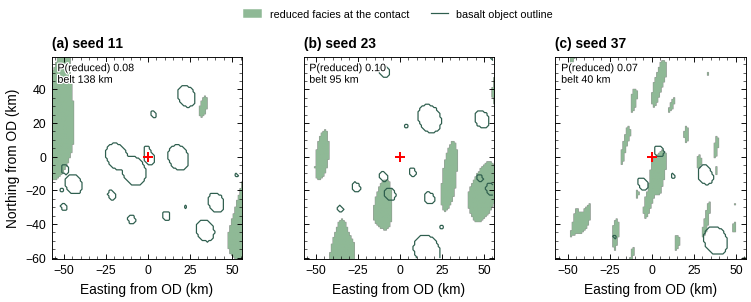

seed 11: P(reduced) drawn 0.082, realized 0.082; belt length 138 km (field correlation 46 by 14 km along 10 deg)
seed 23: P(reduced) drawn 0.105, realized 0.104; belt length 95 km (field correlation 32 by 10 km along 10 deg)
seed 37: P(reduced) drawn 0.066, realized 0.066; belt length 40 km (field correlation 13 by 4 km along 10 deg)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (11, 23, 37)):
    m = MAPS[s]
    ax.imshow(np.where(m["reduced"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#8fb996"]), aspect="equal")
    ax.contour((XC - ODX) / 1e3, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors="#2e5e4e", linewidths=0.8)
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"P(reduced) {o['L3-1 p_reduced']:.2f}\nbelt {o['L3-2 belt_length_km']:.0f} km",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 11", f"(b) seed 23", f"(c) seed 37"))
h = [plt.Rectangle((0, 0), 1, 1, color="#8fb996", label="reduced facies at the contact"),
     plt.Line2D([], [], color="#2e5e4e", lw=0.8, label="basalt object outline")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01))
fig.savefig(FIG / "wp4_PP_03_level3_redox.png", dpi=300)
plt.show()
for s in (11, 23, 37):
    print(f"seed {s}: P(reduced) drawn {OUT[s]['L3-1 p_reduced']:.3f}, realized {OUT[s]['reduced_frac']:.3f}; "
          f"belt length {OUT[s]['L3-2 belt_length_km']:.0f} km (field correlation {OUT[s]['L3-2 belt_length_km']/3:.0f} by "
          f"{OUT[s]['L3-2 belt_length_km']/3/FIX['belt_aspect']:.0f} km along {FIX['belt_az']:.0f} deg)")


### How to read this figure

Pale green is reduced facies, outlines are basalt. Realized fractions match the drawn P(reduced) (0.082, 0.104, 0.066). Long belts (138 km, seed 11) give a few bands; short belts (40 km, seed 37) give many patches.


### Step 4. Level 4, ore rule


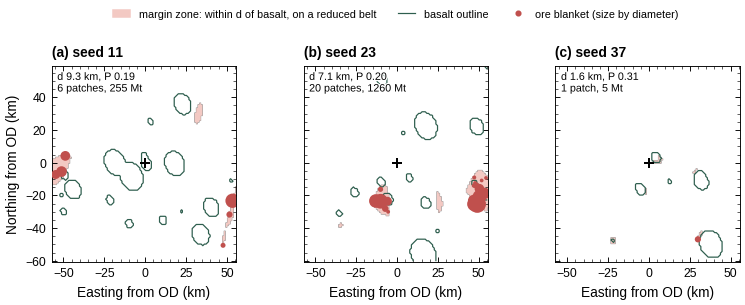

seed 11: margin zone 248 km2, 6 ore patches; blanket depth 440-697 m, thickness 2.1-5.0 m, grade 2.3-3.9%, largest patch 140.6 Mt
seed 23: margin zone 422 km2, 20 ore patches; blanket depth 547-798 m, thickness 1.2-13.6 m, grade 1.5-4.4%, largest patch 317.2 Mt
seed 37: margin zone 47 km2, 1 ore patch; blanket depth 668 m, thickness 1.3 m, grade 4.0%, largest patch 5.2 Mt


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.80, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (11, 23, 37)):
    m = MAPS[s]; e = ORE[s]
    ax.imshow(np.where(m["zone"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#f3c9c3"]), aspect="equal")
    ax.contour((XC - ODX) / 1e3, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors="#2e5e4e", linewidths=0.8)
    if len(e):
        ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, s=4 + 6 * e.diam_km ** 2, c="#c0504d", edgecolors="none", zorder=4)
    ax.plot(0, 0, "+", color="black", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"d {o['L4-1 reach_d_km']:.1f} km, P {o['L4-2 p_ore']:.2f}\n{o['n_ore']} patch{'es' if o['n_ore'] != 1 else ''}, {o['Mt_total']:.0f} Mt",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 11", f"(b) seed 23", f"(c) seed 37"))
h = [plt.Rectangle((0, 0), 1, 1, color="#f3c9c3", label="margin zone: within d of basalt, on a reduced belt"),
     plt.Line2D([], [], color="#2e5e4e", lw=0.8, label="basalt outline"),
     plt.Line2D([], [], color="#c0504d", marker="o", ls="", label="ore blanket (size by diameter)")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.02))
fig.savefig(FIG / "wp4_PP_04_level4_ore.png", dpi=300)
plt.show()
for s in (11, 23, 37):
    e = ORE[s]
    rng = lambda v, f: f"{v.min():{f}}" if len(v) == 1 else f"{v.min():{f}}-{v.max():{f}}"
    msg = (f"; blanket depth {rng(e.depth_m, '.0f')} m, thickness {rng(e.thick_m, '.1f')} m, "
           f"grade {rng(e.grade, '.1f')}%, largest patch {e.Mt.max():.1f} Mt" if len(e) else "")
    print(f"seed {s}: margin zone {OUT[s]['zone_km2']:.0f} km2, {OUT[s]['n_ore']} ore patch{'es' if OUT[s]['n_ore'] != 1 else ''}{msg}")


### How to read this figure

Pink is the margin zone, red dots ore blankets sized by diameter. Seed 11: 248 km2 zone, 6 patches, 255 Mt. Seed 23: 422 km2, 20 patches, 1,260 Mt. Seed 37: 47 km2 (reach 1.6 km), one 5 Mt patch at 668 m.


### Step 5. Level 5, property volumes (seed 11 section)


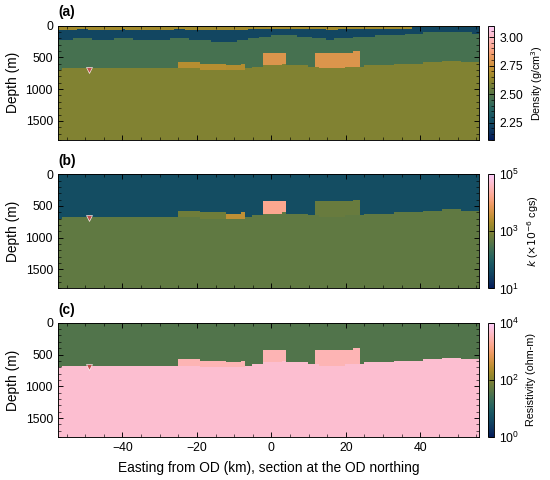

seed 11 unit densities: limestone 2.27, quartzite 2.67, shale and siltstone 2.24, Pandurra 2.46, basement 2.60
basalt objects: density 2.66-3.05, k 293-96920
cover k 47, cover resistivity 34 ohm-m; basalt 3100, basement 5000
ore density increments 0.067-0.115 g/cm3 (grade 2.3-3.9%)


In [9]:
m = MAPS[11]
fig, axes = plt.subplots(3, 1, figsize=(COL15, 4.4), sharex=True)
fig.subplots_adjust(left=0.12, right=0.86, top=0.95, bottom=0.10, hspace=0.30)
zb = np.r_[0, np.cumsum(HZ[::-1][::-1])]                       # layer boundaries, top first
xb = np.r_[XC - DX / 2, XC[-1] + DX / 2]; xbk = (xb - ODX) / 1e3
for ax, key, lab, norm, cmap in [(axes[0], "rho", "Density (g/cm$^3$)", plt.matplotlib.colors.Normalize(2.1, 3.1), BATLOW),
                                  (axes[1], "k", "$k$ ($\\times10^{-6}$ cgs)", plt.matplotlib.colors.LogNorm(10, 1e5), BATLOW),
                                  (axes[2], "res", "Resistivity (ohm-m)", plt.matplotlib.colors.LogNorm(1, 1e4), BATLOW)]:
    sec = m[key][iy].T                                        # (nz, nx)
    pc = ax.pcolormesh(xbk, zb, sec, norm=norm, cmap=cmap, shading="flat", rasterized=True)
    e = ORE[11]; near = e[abs(e.y - ODY) < 5e3] if len(e) else e
    if len(near): ax.plot((near.x - ODX) / 1e3, near.depth_m, "v", color="#c0504d", ms=4, mec="white", mew=0.4)
    ax.set_ylim(1800, 0); ax.set_ylabel("Depth (m)")
    cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02); cb.set_label(lab, fontsize=FS_ANNOT)
axes[-1].set_xlabel("Easting from OD (km), section at the OD northing")
axes[0].set_xlim(xbk[0], xbk[-1])
panel_labels(axes, ("(a)", "(b)", "(c)"))
fig.savefig(FIG / "wp4_PP_05_level5_properties.png", dpi=300)
plt.show()
o = OUT[11]
print(f"seed 11 unit densities: limestone {o['L5-2 rho_limestone']:.2f}, quartzite {o['L5-2 rho_quartzite']:.2f}, "
      f"shale and siltstone {o['L5-2 rho_shale']:.2f}, Pandurra {o['L5-2 rho_pandurra']:.2f}, basement {FIX['rho_basement']:.2f}")
if len(OBJ[11]): print(f"basalt objects: density {OBJ[11].rho.min():.2f}-{OBJ[11].rho.max():.2f}, k {OBJ[11].k.min():.0f}-{OBJ[11].k.max():.0f}")
print(f"cover k {o['L5-2 k_cover']:.0f}, cover resistivity {o['L5-2 res_cover']:.0f} ohm-m; basalt {FIX['res_basalt']:.0f}, basement {FIX['res_basement']:.0f}")
if len(ORE[11]): print(f"ore density increments {ORE[11].drho.min():.3f}-{ORE[11].drho.max():.3f} g/cm3 (grade {ORE[11].grade.min():.1f}-{ORE[11].grade.max():.1f}%)")


### How to read this figure

(a) Density: basalt 2.66 to 3.05 against Pandurra 2.46 and basement 2.60. (b) Susceptibility: cover 47, basement 500, basalt 293 to 96,920 x 1e-6 cgs. (c) Resistivity: cover 34, basalt 3,100, basement 5,000 ohm-m. The triangle is an ore patch; its increment (0.07 to 0.12 g/cm3) is too small to show.


### Step 6. Ensemble of 50, checked against its rows

Seeds 1000 to 1049; draws written to `08_prior_models/wp4_prior_draws_n50.csv`.


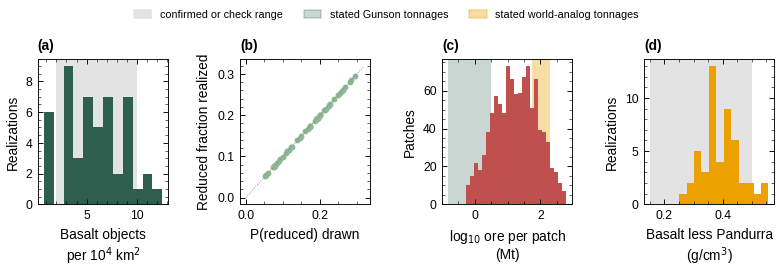

50 realizations; basalt objects per realization 1-17 (median 8); realizations with no basalt 0
reduced fraction realized minus drawn: max |diff| 0.000
ore patches per realization 0-96 (median 16); with no ore 6
ore per patch 0.53-625 Mt, median 19.0 Mt; 14% at or below the largest Gunson figure (3.2 Mt), 24.7% at or above the smallest world analog (57 Mt), 5.4% above the largest (198 Mt), 61% in the gap between the two
patches inside the 1974 circles: 23% (circles cover 6.6% of the window)
basalt less Pandurra density 0.25-0.56, median 0.38; inside 0.15-0.5: 94% of realizations with basalt
draws table written: wp4_prior_draws_n50.csv (50 rows, 26 columns)


In [10]:
N = 50
rows, all_ore = [], []
for s in range(1000, 1000 + N):
    o, _, b, e = realize(s)
    rows.append(o)
    if len(e): all_ore.append(e.assign(seed=s))
EN = pd.DataFrame(rows); ORES = pd.concat(all_ore, ignore_index=True) if all_ore else pd.DataFrame()
EN.to_csv(TAB / "wp4_prior_draws_n50.csv", index=False)
gun = [float(x) for x in re.findall(r"Gunson (\d+\.?\d*)-(\d+\.?\d*) Mt", CT.loc["L4-4", "evidence_and_translation"])[0]]
wld = [float(x) for x in re.findall(r"world (\d+)-(\d+) Mt", CT.loc["L4-4", "evidence_and_translation"])[0]]
fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.4))
fig.subplots_adjust(left=0.06, right=0.99, top=0.80, bottom=0.25, wspace=0.55)
ax = axes[0]; ax.hist(EN.n_basalt / AREA_KM2 * 1e4, bins=12, color="#2e5e4e"); ax.axvspan(2, 10, color=ANNEX_GREY, zorder=0, lw=0)
ax.set_xlabel("Basalt objects\nper 10$^4$ km$^2$"); ax.set_ylabel("Realizations")
ax = axes[1]; ax.scatter(EN["L3-1 p_reduced"], EN.reduced_frac, s=8, color="#8fb996"); ax.plot([0, 0.32], [0, 0.32], color="0.5", lw=0.6, ls=":")
ax.set_xlabel("P(reduced) drawn\n"); ax.set_ylabel("Reduced fraction realized")
ax = axes[2]
if len(ORES): ax.hist(np.log10(ORES.Mt), bins=25, color="#c0504d")
ax.axvspan(np.log10(gun[0]), np.log10(gun[1]), color="#2e5e4e", alpha=0.25, lw=0, zorder=0)
ax.axvspan(np.log10(wld[0]), np.log10(wld[1]), color="#eda100", alpha=0.35, lw=0, zorder=0)
ax.set_xlabel("log$_{10}$ ore per patch\n(Mt)"); ax.set_ylabel("Patches")
ax = axes[3]; ax.hist(EN.contrast.dropna(), bins=12, color="#eda100"); ax.axvspan(0.15, 0.5, color=ANNEX_GREY, zorder=0, lw=0)
ax.set_xlabel("Basalt less Pandurra\n(g/cm$^3$)"); ax.set_ylabel("Realizations")
panel_labels(axes, ("(a)", "(b)", "(c)", "(d)"))
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="confirmed or check range"),
     plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.25, label="stated Gunson tonnages"),
     plt.Rectangle((0, 0), 1, 1, color="#eda100", alpha=0.35, label="stated world-analog tonnages")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_PP_06_ensemble_checks.png", dpi=300)
plt.show()
print(f"{N} realizations; basalt objects per realization {EN.n_basalt.min()}-{EN.n_basalt.max()} (median {EN.n_basalt.median():.0f}); "
      f"realizations with no basalt {int((EN.n_basalt == 0).sum())}")
print(f"reduced fraction realized minus drawn: max |diff| {abs(EN.reduced_frac - EN['L3-1 p_reduced']).max():.3f}")
print(f"ore patches per realization {EN.n_ore.min()}-{EN.n_ore.max()} (median {EN.n_ore.median():.0f}); with no ore {int((EN.n_ore == 0).sum())}")
if len(ORES):
    print(f"ore per patch {ORES.Mt.min():.2f}-{ORES.Mt.max():.0f} Mt, median {ORES.Mt.median():.1f} Mt; "
          f"{(ORES.Mt <= gun[1]).mean()*100:.0f}% at or below the largest Gunson figure ({gun[1]} Mt), "
          f"{(ORES.Mt >= wld[0]).mean()*100:.1f}% at or above the smallest world analog ({wld[0]:.0f} Mt), "
          f"{(ORES.Mt > wld[1]).mean()*100:.1f}% above the largest ({wld[1]:.0f} Mt), "
          f"{((ORES.Mt > gun[1]) & (ORES.Mt < wld[0])).mean()*100:.0f}% in the gap between the two")
    print(f"patches inside the 1974 circles: {ORES.in_circle.mean()*100:.0f}% (circles cover {IN_CIRCLE.mean()*100:.1f}% of the window)")
print(f"basalt less Pandurra density {EN.contrast.min():.2f}-{EN.contrast.max():.2f}, median {EN.contrast.median():.2f}; "
      f"inside 0.15-0.5: {((EN.contrast >= 0.15) & (EN.contrast <= 0.5)).mean()*100:.0f}% of realizations with basalt")
print(f"draws table written: wp4_prior_draws_n50.csv ({EN.shape[0]} rows, {EN.shape[1]} columns)")


### How to read this figure

(a) Basalt objects per 10,000 km2 against the 2 to 10 row range; Poisson scatter takes some realizations outside it (1 to 17 objects, median 8). (b) Reduced fraction realized equals drawn. (c) Tonnage per patch against the Gunson (0.15 to 3.2 Mt) and world (57 to 198 Mt) clusters: median 19 Mt, 61% between the clusters, 5.4% above 198 Mt. (d) Basalt less Pandurra density, median 0.38; 94% inside 0.15 to 0.5.


### Step 7. The three prior models in 3D


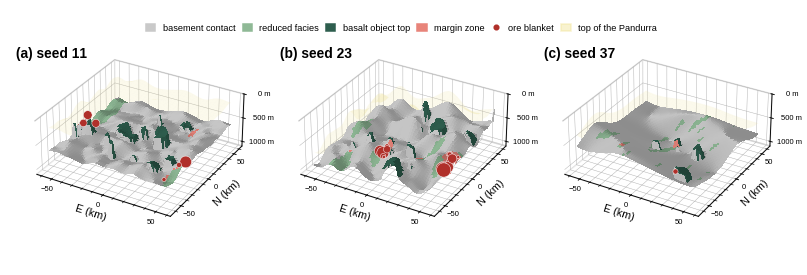

seed 11: 19 basalt objects, reduced 8% of the contact, 6 ore blankets totalling 255 Mt; contact 334-763 m deep
seed 23: 15 basalt objects, reduced 10% of the contact, 20 ore blankets totalling 1260 Mt; contact 290-1008 m deep
seed 37: 9 basalt objects, reduced 7% of the contact, 1 ore blanket totalling 5 Mt; contact 247-912 m deep


In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LightSource, to_rgba
st = 2                                                        # plot every 2nd cell (2 km) for a readable surface
Xk, Yk = (GX[::st, ::st] - ODX) / 1e3, (GY[::st, ::st] - ODY) / 1e3
CAT = {0: "#c9c9c9", 1: "#8fb996", 2: "#2e5e4e", 3: "#e8847a"}
LS = LightSource(azdeg=315, altdeg=40)
fig = plt.figure(figsize=(COL2, 2.9))
fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0, wspace=0.0)
for j, s in enumerate((11, 23, 37)):
    ax = fig.add_subplot(1, 3, j + 1, projection="3d", computed_zorder=False)
    ax.patch.set_alpha(0.0)                                   # transparent so a neighbour's tick labels are not hidden
    m = MAPS[s]; e = ORE[s]
    cat = np.zeros((NY, NX), int); cat[m["reduced"]] = 1; cat[m["bid"] > 0] = 2; cat[m["zone"]] = 3
    cat = cat[::st, ::st]; zc = -m["contact"][::st, ::st]
    rgb = np.array([to_rgba(CAT[c]) for c in range(4)])[cat]
    hs = LS.hillshade(zc, vert_exag=20, dx=st, dy=st)[..., None]
    rgb[..., :3] *= 0.70 + 0.30 * hs
    ax.plot_surface(Xk, Yk, -m["cover"][::st, ::st], color="#f2e6a0", alpha=0.20, linewidth=0, shade=False, zorder=1)
    ax.plot_surface(Xk, Yk, zc, facecolors=rgb, rstride=1, cstride=1, linewidth=0, antialiased=False, shade=False, zorder=2)
    if len(e):
        ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, -e.depth_m + 20, s=3 + 4 * e.diam_km ** 2, c="#b0302a",
                   edgecolors="white", linewidths=0.3, depthshade=False, zorder=5)
    ax.set_zlim(-1100, 0); ax.set_box_aspect((1, 1, 0.40), zoom=0.82); ax.view_init(elev=30, azim=-60)
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_facecolor((1, 1, 1, 0)); a.pane.set_edgecolor("0.75"); a._axinfo["grid"]["linewidth"] = 0.3
    ax.set_xticks([-50, 0, 50]); ax.set_yticks([-50, 0, 50])
    ax.set_xlabel("E (km)", fontsize=FS_ANNOT, labelpad=-8); ax.set_ylabel("N (km)", fontsize=FS_ANNOT, labelpad=-8)
    ax.tick_params(labelsize=FS_ANNOT - 2, pad=-3); ax.tick_params(axis="z", pad=1)
    ax.set_zticks([-1000, -500, 0]); ax.set_zticklabels(["1000 m", "500 m", "0 m"])
    ax.text2D(0.04, 0.80, f"({'abc'[j]}) seed {s}", transform=ax.transAxes, fontsize=FS_PANEL, fontweight="bold")
h = [plt.Rectangle((0, 0), 1, 1, color=CAT[0], label="basement contact"), plt.Rectangle((0, 0), 1, 1, color=CAT[1], label="reduced facies"),
     plt.Rectangle((0, 0), 1, 1, color=CAT[2], label="basalt object top"), plt.Rectangle((0, 0), 1, 1, color=CAT[3], label="margin zone"),
     plt.Line2D([], [], color="#b0302a", marker="o", ls="", label="ore blanket"),
     plt.Rectangle((0, 0), 1, 1, color="#f2e6a0", alpha=0.5, label="top of the Pandurra")]
fig.legend(handles=h, loc="upper center", ncol=6, fontsize=FS_ANNOT - 1, bbox_to_anchor=(0.5, 0.88), handlelength=1.0, columnspacing=0.8, frameon=False)
fig.savefig(FIG / "wp4_PP_07_three_prior_models_3d.png", dpi=300)
plt.show()
for s in (11, 23, 37):
    o = OUT[s]
    print(f"seed {s}: {o['n_basalt']} basalt objects, reduced {o['reduced_frac']*100:.0f}% of the contact, "
          f"{o['n_ore']} ore blanket{'s' if o['n_ore'] != 1 else ''} totalling {o['Mt_total']:.0f} Mt; contact {MAPS[s]['contact'].min():.0f}-{MAPS[s]['contact'].max():.0f} m deep")


### How to read this figure

Basement contact (raised to the basalt top where basalt is present) seen from the south-east, vertical exaggeration about 40. Green is reduced facies, salmon the margin zone, red dots ore, yellow the top of the Pandurra. Seed 11: contact 334 to 763 m, 255 Mt. Seed 23: 290 to 1,008 m, 1,260 Mt. Seed 37: 247 to 912 m, 5 Mt.


## Section 4. Prior predictive check

The assembled sampler is checked as a whole: realizations are forward-modelled and the statistics of their anomalies (count per area, amplitude, width) are compared with the real t0 surveys. The check is a QC gate, diagnostic only. Nothing here feeds back into a parameter; a gross mismatch goes back to the levels as a numbered change to the citation table.


### Step 8. Observed surveys and the anomaly rule

The observed data are opened here for the first time: 342 BMR gravity stations (1969) and the P234 aeromagnetic lines (1962, 1.6 km spacing, 150 m clearance, channel `mag_awagsLevelled`). The rule is fixed in `RULE` before any statistic is computed: remove a least-squares plane, grid linearly onto the 1 km mesh, call an anomaly any 3 or more connected cells above 2 mGal or 20 nT. Synthetic data get noise from the station accuracy columns (1.0 mGal) and a declared 5 nT. Magnetization is induced only, in the April 1962 field (DGRF).


In [12]:
import netCDF4
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator

PM = Path(".")                                               # this notebook sits in the SVOI_OD folder
OBS = PM / "04_prior_predictive_observed"

# ---- the anomaly rule: fixed here, before any observed statistic is computed ------------------------------------------
RULE = dict(T_grav_mgal=2.0,          # anomaly threshold, twice the station noise (about 1 mGal, below)
            T_mag_nt=20.0,            # anomaly threshold, four times the declared 1962 reading noise
            mag_noise_nt=5.0,         # declared white noise on the 1962 readings
            min_cells=3,              # an anomaly is at least 3 connected 1 km cells (3 km2)
            mag_decimate=4,           # every 4th reading along line (about 270 m)
            elev_gradient=0.1967)     # Bouguer elevation factor, mGal/m at 2.67 g/cm3
FIELD = dict(F_nt=57776.0, inc=-62.44, dec=6.00, clearance_m=150.0)   # April 1962 field at the deposit (DGRF); P234 clearance
N_ENS, SEED0 = 200, 1000

# ---- observed: 342 BMR stations (1969) and the P234 lines (1962) in the regional window -------------------------------
gv = pd.read_csv(OBS / "gravity_stations_pre1975_regional.csv")
GXo, GYo = to_mga.transform(gv.LONGITUDE.values, gv.LATITUDE.values)
G_OBS = gv.SPHERICAL_CAP_BOUGUER_ANOMALY.values / 10.0                  # um/s2 to mGal
G_SD = np.sqrt((gv.ACCURACY_OF_OBSERVED_GRAVITY.values / 10.0) ** 2 + (RULE["elev_gradient"] * gv.ACCURACY_OF_GEOID_GND_ELEV.values) ** 2)
ds = netCDF4.Dataset(OBS / "P234-line-magnetic-AWAGS_MAG_2010.nc")
lon, lat = np.asarray(ds["longitude"][:], float), np.asarray(ds["latitude"][:], float)
mag, line = np.asarray(ds["mag_awagsLevelled"][:], float), np.asarray(ds["line_index"][:])
w = (lon >= WIN.lon_min) & (lon <= WIN.lon_max) & (lat >= WIN.lat_min) & (lat <= WIN.lat_max) & np.isfinite(mag)
idx = np.flatnonzero(w)[::RULE["mag_decimate"]]
MXo, MYo = to_mga.transform(lon[idx], lat[idx]); M_OBS = mag[idx]; M_LINE = line[idx]
print(f"gravity: {len(G_OBS)} stations, noise sd {np.median(G_SD):.2f} mGal (observed gravity 0.2 mGal, elevation 5 m)")
print(f"magnetics: {w.sum():,} readings on {len(np.unique(line[w]))} line segments in the window, {len(M_OBS):,} used")
print("rule:", RULE); print("field:", FIELD)


gravity: 342 stations, noise sd 1.00 mGal (observed gravity 0.2 mGal, elevation 5 m)
magnetics: 99,920 readings on 128 line segments in the window, 24,980 used
rule: {'T_grav_mgal': 2.0, 'T_mag_nt': 20.0, 'mag_noise_nt': 5.0, 'min_cells': 3, 'mag_decimate': 4, 'elev_gradient': 0.1967}
field: {'F_nt': 57776.0, 'inc': -62.44, 'dec': 6.0, 'clearance_m': 150.0}


### Reading the output

Gravity noise is dominated by the 5 m elevation accuracy (5 m x 0.197 mGal/m). 24,980 magnetic readings are used, every fourth along line.


### Step 9. Forward operator and its check against SimPEG

Gravity at the ground and total-field anomaly at 150 m are computed layer by layer with FFTs on the sampler mesh, which takes about 0.25 s per realization. The operator is checked against SimPEG's integral solution for a 6 x 6 km block 400 to 600 m deep.


forward operator ready: 256 x 256 padded grid, 86 layers


SimPEG 0.24.0: test block 6 x 6 km, 400-600 m, +0.30 g/cm3 and 10,000 x 1e-6 cgs
gravity peak 2.12 mGal (SimPEG) vs 2.12 (FFT); magnetics -218 to 356 nT vs -237 to 390
{'grav_peak_ratio': 1.0, 'grav_rms_rel': 0.001, 'mag_peak_ratio': 1.095, 'mag_trough_ratio': 1.091, 'mag_rms_rel': 0.003}


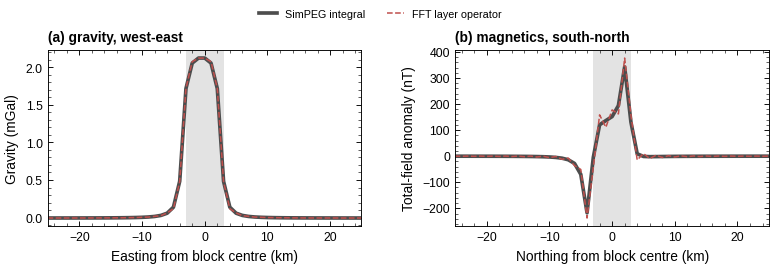

In [13]:
# ---- layer-by-layer FFT forward operator on the sampler mesh (Blakely 1995, eqs 11.35 and 11.44 form) -------------------
PADN = 256
PY, PX = (PADN - NY) // 2, (PADN - NX) // 2
KX, KY = np.meshgrid(2 * np.pi * np.fft.fftfreq(PADN, DX), 2 * np.pi * np.fft.fftfreq(PADN, DX))
K = np.hypot(KX, KY); K[0, 0] = 1e-12
ZT = np.r_[0.0, np.cumsum(HZ[:-1])]; ZB = np.cumsum(HZ)                 # layer tops and bottoms (m), top first
I, D = np.radians(FIELD["inc"]), np.radians(FIELD["dec"])
fx, fy, fz = np.cos(I) * np.sin(D), np.cos(I) * np.cos(D), np.sin(I)    # east, north, down
THETA2 = (fz + 1j * (fx * KX + fy * KY) / K) ** 2                        # induced: magnetization parallel to the field
h = FIELD["clearance_m"]
EG = [(np.exp(-K * a) - np.exp(-K * b)) / K for a, b in zip(ZT, ZB)]
EM = [np.exp(-K * (a + h)) - np.exp(-K * (b + h)) for a, b in zip(ZT, ZB)]
GCONST, MU0 = 6.674e-11, 4e-7 * np.pi

def pad(a):
    return np.pad(a, ((PY, PADN - NY - PY), (PX, PADN - NX - PX)), mode="reflect")

def forward(rho, k_cgs):
    """gravity at the ground (mGal) and total-field anomaly at 150 m (nT) on the map grid, from (NY, NX, NZ) volumes"""
    g = np.zeros((PADN, PADN), complex); t = np.zeros((PADN, PADN), complex)
    M = k_cgs * 1e-6 * 4 * np.pi * FIELD["F_nt"] * 1e-9 / MU0            # cgs susceptibility to SI, induced magnetization (A/m)
    for l in range(rho.shape[2]):
        r, m = rho[:, :, l], M[:, :, l]
        if np.ptp(r) > 0: g += np.fft.fft2(pad(r - r.mean())) * EG[l]
        if np.ptp(m) > 0: t += np.fft.fft2(pad(m - m.mean())) * EM[l]
    g *= 2 * np.pi * GCONST * 1000.0 * 1e5; t *= 2 * np.pi * 1e-7 * THETA2 * 1e9
    g[0, 0] = t[0, 0] = 0
    crop = (slice(PY, PY + NY), slice(PX, PX + NX))
    return np.real(np.fft.ifft2(g))[crop], np.real(np.fft.ifft2(t))[crop]

# ---- the same statistics on observed and synthetic data -------------------------------------------------------------------
TRI_G, TRI_M = Delaunay(np.c_[GXo, GYo]), Delaunay(np.c_[MXo, MYo])

def detrend(x, y, v):
    A = np.c_[np.ones_like(x), (x - X0) / 1e3, (y - Y0) / 1e3]
    return v - A @ np.linalg.lstsq(A, v, rcond=None)[0]

def anomaly_stats(tri, x, y, v, T):
    res = detrend(x, y, v)
    grid = LinearNDInterpolator(tri, res)(GX, GY)
    ok = np.isfinite(grid)
    lab, n = ndimage.label(ok & (grid >= T), structure=np.ones((3, 3)))
    size = ndimage.sum(np.ones_like(grid), lab, np.arange(1, n + 1)); keep = size >= RULE["min_cells"]
    peak = np.asarray(ndimage.maximum(np.where(ok, grid, -np.inf), lab, np.arange(1, n + 1)))[keep]
    width = 2 * np.sqrt(size[keep] / np.pi)                              # km, cells are 1 km2
    s = dict(n_per_1e4km2=keep.sum() / ok.sum() * 1e4, amp_median=np.median(peak) if len(peak) else np.nan,
             amp_p90=np.percentile(peak, 90) if len(peak) else np.nan, width_median_km=np.median(width) if len(width) else np.nan,
             residual_sd=res.std())
    return s, grid, np.isin(lab, np.flatnonzero(keep) + 1)

def sample(field, x, y):
    return RegularGridInterpolator((YC, XC), field, bounds_error=False, fill_value=None)(np.c_[y, x])

def synthetic(seed, rng_noise=True):
    out, maps, objs, ores = realize(seed, keep_volume=True)
    g, t = forward(maps["rho"], maps["k"])
    r = np.random.default_rng(seed + 10_000_000)
    gs = sample(g, GXo, GYo) + (r.normal(0, G_SD) if rng_noise else 0)
    ms = sample(t, MXo, MYo) + (r.normal(0, RULE["mag_noise_nt"], len(MXo)) if rng_noise else 0)
    return out, maps, g, t, gs, ms

OBS_G, GRID_G, ANOM_G = anomaly_stats(TRI_G, GXo, GYo, G_OBS, RULE["T_grav_mgal"])
OBS_M, GRID_M, ANOM_M = anomaly_stats(TRI_M, MXo, MYo, M_OBS, RULE["T_mag_nt"])
print("forward operator ready:", PADN, "x", PADN, "padded grid,", len(ZT), "layers")

# ---- check the FFT operator against SimPEG's integral solution for one test body ---------------------------------------
import simpeg
from simpeg import maps as smaps
from simpeg.potential_fields import gravity as sgrav, magnetics as smag
jc, ic = NY // 2, NX // 2; L1, L2 = 16, 24                            # a 6 x 6 km block, 400 to 600 m deep
rho_t = np.zeros((NY, NX, len(ZC))); k_t = np.zeros_like(rho_t)
rho_t[jc - 3:jc + 3, ic - 3:ic + 3, L1:L2] = 0.30                        # g/cm3
k_t[jc - 3:jc + 3, ic - 3:ic + 3, L1:L2] = 10000.0                       # 1e-6 cgs
g_fft, t_fft = forward(rho_t, k_t)
bm = discretize.TensorMesh([[DX] * 6, [DX] * 6, [25.0] * (L2 - L1)], origin=[XC[ic - 3] - DX / 2, YC[jc - 3] - DX / 2, -ZB[L2 - 1]])
rx_xy = np.c_[GX.ravel(), GY.ravel()]
sv_g = sgrav.survey.Survey(sgrav.sources.SourceField([sgrav.receivers.Point(np.c_[rx_xy, np.zeros(len(rx_xy))], components="gz")]))
sim_g = sgrav.simulation.Simulation3DIntegral(bm, survey=sv_g, rhoMap=smaps.IdentityMap(nP=bm.n_cells), active_cells=np.ones(bm.n_cells, bool), store_sensitivities="forward_only")
g_sp = -sim_g.dpred(np.full(bm.n_cells, 0.30)).reshape(NY, NX)     # SimPEG gz is positive up; the FFT operator is positive down
rx_m = smag.receivers.Point(np.c_[rx_xy, np.full(len(rx_xy), h)], components="tmi")
src_m = smag.sources.UniformBackgroundField(receiver_list=[rx_m], amplitude=FIELD["F_nt"], inclination=FIELD["inc"], declination=FIELD["dec"])
sim_m = smag.simulation.Simulation3DIntegral(bm, survey=smag.survey.Survey(src_m), chiMap=smaps.IdentityMap(nP=bm.n_cells), active_cells=np.ones(bm.n_cells, bool), store_sensitivities="forward_only")
t_sp = sim_m.dpred(np.full(bm.n_cells, 10000.0 * 1e-6 * 4 * np.pi)).reshape(NY, NX)
g_sp_d, t_sp_d = g_sp - g_sp.mean(), t_sp - t_sp.mean()               # the FFT field has its mean removed; compare like with like
g_ff_d, t_ff_d = g_fft - g_fft.mean(), t_fft - t_fft.mean()
TEST_ERR = dict(grav_peak_ratio=g_ff_d.max() / g_sp_d.max(), grav_rms_rel=np.sqrt(np.mean((g_ff_d - g_sp_d) ** 2)) / np.ptp(g_sp_d),
                mag_peak_ratio=t_ff_d.max() / t_sp_d.max(), mag_trough_ratio=t_ff_d.min() / t_sp_d.min(),
                mag_rms_rel=np.sqrt(np.mean((t_ff_d - t_sp_d) ** 2)) / np.ptp(t_sp_d))
print(f"SimPEG {simpeg.__version__}: test block 6 x 6 km, 400-600 m, +0.30 g/cm3 and 10,000 x 1e-6 cgs")
print(f"gravity peak {g_sp_d.max():.2f} mGal (SimPEG) vs {g_ff_d.max():.2f} (FFT); magnetics {t_sp_d.min():.0f} to {t_sp_d.max():.0f} nT vs {t_ff_d.min():.0f} to {t_ff_d.max():.0f}")
print({k: round(float(v), 3) for k, v in TEST_ERR.items()})

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.5))
fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.2, wspace=0.3)
xk = (XC - XC[ic]) / 1e3; yk = (YC - YC[jc]) / 1e3
axes[0].plot(xk, g_sp_d[jc], color="0.3", lw=2.4, label="SimPEG integral")
axes[0].plot(xk, g_ff_d[jc], color="#c0504d", lw=1.0, ls="--", label="FFT layer operator")
axes[0].set_xlabel("Easting from block centre (km)"); axes[0].set_ylabel("Gravity (mGal)")
axes[1].plot(yk, t_sp_d[:, ic], color="0.3", lw=2.4); axes[1].plot(yk, t_ff_d[:, ic], color="#c0504d", lw=1.0, ls="--")
axes[1].set_xlabel("Northing from block centre (km)"); axes[1].set_ylabel("Total-field anomaly (nT)")
for ax in axes: ax.set_xlim(-25, 25); ax.axvspan(-3, 3, color=ANNEX_GREY, zorder=0, lw=0)
panel_labels(axes, ("(a) gravity, west-east", "(b) magnetics, south-north"))
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.savefig(FIG / "wp4_PP_08_forward_check.png", dpi=300)
plt.show()


### How to read this figure

Grey is SimPEG, red dashed the FFT operator, grey band the block. Gravity agrees to 0.1% RMS of the anomaly range and the peaks match (2.12 mGal). Magnetics agrees to 0.3% RMS; the FFT peak and trough are about 9% high at the block edges, an effect of the 1 km cells. The negative lobe lies to the south, as expected for induced magnetization at inclination -62 degrees.


### Step 10. Observed surveys against one realization (seed 11)


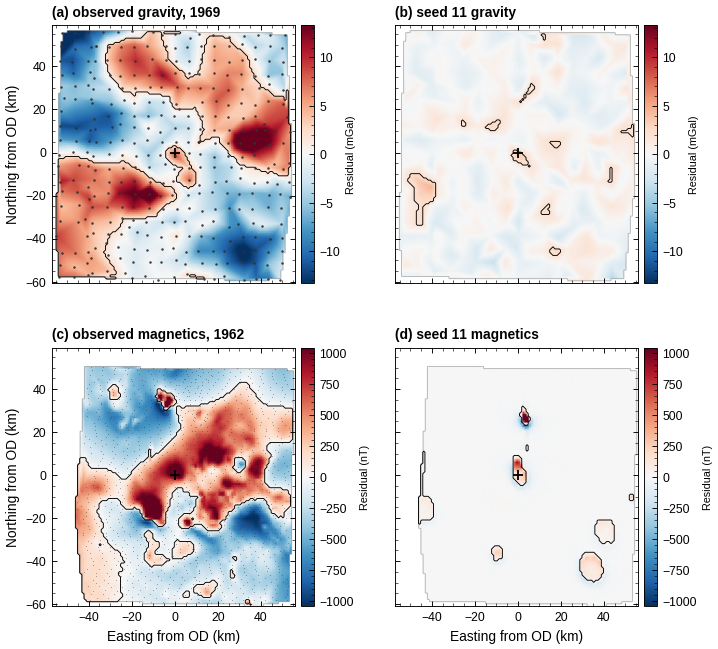

gravity   observed {'n_per_1e4km2': 4.1, 'amp_median': 8.04, 'amp_p90': 20.37, 'width_median_km': 13.49, 'residual_sd': 6.49}
          seed 11  {'n_per_1e4km2': 9.02, 'amp_median': 2.46, 'amp_p90': 3.31, 'width_median_km': 4.22, 'residual_sd': 1.2}
magnetics observed {'n_per_1e4km2': 9.35, 'amp_median': 398.08, 'amp_p90': 3127.72, 'width_median_km': 7.3, 'residual_sd': 475.5}
          seed 11  {'n_per_1e4km2': 7.48, 'amp_median': 253.26, 'amp_p90': 1558.71, 'width_median_km': 7.46, 'residual_sd': 88.79}


In [14]:
out11, maps11, g11, t11, gs11, ms11 = synthetic(11)
SYN_G11, SGRID_G, SANOM_G = anomaly_stats(TRI_G, GXo, GYo, gs11, RULE["T_grav_mgal"])
SYN_M11, SGRID_M, SANOM_M = anomaly_stats(TRI_M, MXo, MYo, ms11, RULE["T_mag_nt"])
fig, axes = plt.subplots(2, 2, figsize=(COL2, 6.0))
fig.subplots_adjust(left=0.08, right=0.9, top=0.95, bottom=0.07, wspace=0.12, hspace=0.25)
lim_g = np.nanpercentile(abs(GRID_G), 98); lim_m = np.nanpercentile(abs(GRID_M), 98)
for ax, grid, anom, lim, lab in [(axes[0, 0], GRID_G, ANOM_G, lim_g, "mGal"), (axes[0, 1], SGRID_G, SANOM_G, lim_g, "mGal"),
                                  (axes[1, 0], GRID_M, ANOM_M, lim_m, "nT"), (axes[1, 1], SGRID_M, SANOM_M, lim_m, "nT")]:
    im = ax.imshow(grid, origin="lower", extent=ext, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, anom.astype(float), levels=[0.5], colors="k", linewidths=0.6)
    ax.plot(0, 0, "+", color="k", ms=7, mew=1.2); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02); cb.set_label(f"Residual ({lab})", fontsize=FS_ANNOT)
axes[0, 0].plot((GXo - ODX) / 1e3, (GYo - ODY) / 1e3, ".", color="0.2", ms=1.2)
axes[1, 0].plot((MXo[::20] - ODX) / 1e3, (MYo[::20] - ODY) / 1e3, ",", color="0.2", alpha=0.4)
for ax in axes[1]: ax.set_xlabel("Easting from OD (km)")
for ax in axes[:, 0]: ax.set_ylabel("Northing from OD (km)")
for ax in axes[:, 1]: ax.set_yticklabels([])
for ax in axes[0]: ax.set_xticklabels([])
panel_labels(axes.ravel(), ("(a) observed gravity, 1969", "(b) seed 11 gravity", "(c) observed magnetics, 1962", "(d) seed 11 magnetics"))
fig.savefig(FIG / "wp4_PP_09_observed_vs_seed11.png", dpi=300)
plt.show()
show = lambda s: {k: round(float(v), 2) for k, v in s.items()}
print("gravity   observed", show(OBS_G)); print("          seed 11 ", show(SYN_G11))
print("magnetics observed", show(OBS_M)); print("          seed 11 ", show(SYN_M11))


### How to read this figure

Residuals after the plane is removed, same colour scale per row; black outlines are the detected anomalies. (a) Observed gravity is dominated by broad highs and lows of 10 to 15 mGal over tens of km. (b) Seed 11 makes only small anomalies near 2.5 mGal. (c) Observed magnetics shows a broad high through the centre with peaks over 1,000 nT. (d) Seed 11 puts its magnetic anomalies on the basalt objects, similar in size but isolated. Residual sd: gravity 6.5 mGal observed against 1.2 for seed 11; magnetics 476 nT against 89.


### Step 11. The predictive ensemble

200 realizations (seeds 1000 to 1199, which include the 50 of Step 6), each forward-modelled, sampled at the real station and line positions, given noise, and scored with the same rule. Written to `08_prior_models/wp4_prior_predictive_stats_n200.csv`.


In [15]:
import time
t0 = time.time(); rows = []
for s in range(SEED0, SEED0 + N_ENS):
    o, mp, g, t, gs, ms = synthetic(s)
    sg, _, _ = anomaly_stats(TRI_G, GXo, GYo, gs, RULE["T_grav_mgal"]); sm, _, _ = anomaly_stats(TRI_M, MXo, MYo, ms, RULE["T_mag_nt"])
    rows.append({**{k: v for k, v in o.items()}, **{"g_" + k: v for k, v in sg.items()}, **{"m_" + k: v for k, v in sm.items()}})
PP = pd.DataFrame(rows); PP.to_csv(TAB / "wp4_prior_predictive_stats_n200.csv", index=False)
print(f"{N_ENS} realizations (seeds {SEED0}-{SEED0 + N_ENS - 1}) forward-modelled and scored in {time.time() - t0:.0f} s")
print("written: wp4_prior_predictive_stats_n200.csv", PP.shape)


200 realizations (seeds 1000-1199) forward-modelled and scored in 48 s
written: wp4_prior_predictive_stats_n200.csv (200, 36)


### Reading the output

About 51 s for the 200 realizations.


### Step 12. The gate

Each statistic is scored by the quantile of the observed value in the ensemble: PASS inside 5 to 95%, WARN outside that but inside the ensemble range, FAIL outside the range. Written to `wp4_prior_predictive_gate.csv`.


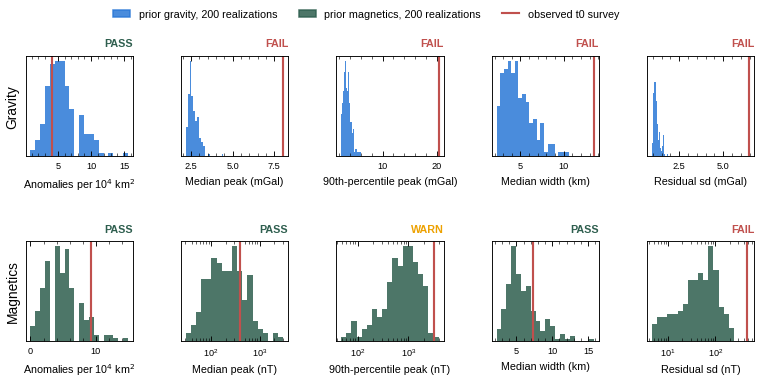

    field       statistic  observed  sim_p05  sim_median  sim_p95  sim_min  sim_max  quantile status
  gravity    n_per_1e4km2     4.101    2.460       5.741    9.842    0.820   15.583     0.268   PASS
  gravity      amp_median     8.043    2.305       2.572    3.141    2.198    4.456     1.000   FAIL
  gravity         amp_p90    20.374    2.532       3.415    4.719    2.353    6.045     1.000   FAIL
  gravity width_median_km    13.493    2.523       4.370    7.665    2.239   10.645     1.000   FAIL
  gravity     residual_sd     6.485    1.016       1.149    1.579    0.953    1.872     1.000   FAIL
magnetics    n_per_1e4km2     9.352    0.935       4.676    9.352    0.000   14.963     0.940   PASS
magnetics      amp_median   398.080   57.360     206.351  853.292   33.911 2790.944     0.759   PASS
magnetics         amp_p90  3127.721  128.554     820.571 2168.693   53.105 3555.196     0.995   WARN
magnetics width_median_km     7.298    3.192       5.518    9.949    2.257   15.797     0.7

In [16]:
STATS = [("n_per_1e4km2", "Anomalies per 10$^4$ km$^2$", False), ("amp_median", "Median peak", True),
         ("amp_p90", "90th-percentile peak", True), ("width_median_km", "Median width (km)", False), ("residual_sd", "Residual sd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]
    q = (sim < obs).mean() + 0.5 * (sim == obs).mean()
    status = "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
    return q, status
GATE = []
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6))
fig.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.14, wspace=0.45, hspace=0.85)
for r, (f, obs, col) in enumerate([("g", OBS_G, "#2a78d6"), ("m", OBS_M, "#2e5e4e")]):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r, c]; sim = PP[f"{f}_{key}"].dropna(); o = obs[key]
        allv = np.r_[sim.values, o]
        logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        bins = np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 20) if logx else 20
        ax.hist(sim, bins=bins, color=col, alpha=0.85)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color="#c0504d", lw=1.4)
        q, st = gate(sim, o); GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o,
                                               sim_p05=np.percentile(sim, 5), sim_median=np.median(sim), sim_p95=np.percentile(sim, 95),
                                               sim_min=sim.min(), sim_max=sim.max(), quantile=q, status=st))
        ax.set_title(st, loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"PASS": "#2e5e4e", "WARN": "#eda100", "FAIL": "#c0504d"}[st])
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else ""), fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
        ax.set_yticks([])
axes[0, 0].set_ylabel("Gravity", fontsize=FS_LABEL); axes[1, 0].set_ylabel("Magnetics", fontsize=FS_LABEL)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2a78d6", alpha=0.85, label=f"prior gravity, {N_ENS} realizations"),
                    plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.85, label=f"prior magnetics, {N_ENS} realizations"),
                    plt.Line2D([], [], color="#c0504d", lw=1.4, label="observed t0 survey")],
           loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_PP_10_predictive_statistics.png", dpi=300)
plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(TAB / "wp4_prior_predictive_gate.csv", index=False)
print(GATE.round(3).to_string(index=False))


### How to read this figure

Histograms are the 200 realizations, the red line the observed survey. **Gravity fails on four of five statistics.** The anomaly count passes (4.1 per 10,000 km2 against a median of 5.7), but observed anomalies are far larger and wider than any realization: median peak 8.0 mGal against at most 4.5, 90th-percentile peak 20.4 against at most 6.0, median width 13.5 km against at most 10.6, residual sd 6.5 mGal against at most 1.9. **Magnetics mostly passes.** Count, median peak and width sit inside the ensemble (quantiles 0.94, 0.76, 0.79); the 90th-percentile peak is a WARN (3,128 nT, quantile 0.995); only the residual sd fails (476 nT against at most 246).


### Step 13. What drives the failing statistics

Rank correlation across the 200 realizations between each failing statistic and the prior draws. Diagnostic only: it says which level to revisit, not what value to give it.


In [17]:
# which prior draws move the failing statistics: rank correlation across the ensemble (diagnostic only, never used to refit)
DRAWS = [c for c in PP.columns if c[:2] in ("L1", "L2", "L3", "L4", "L5")] + ["basalt_frac", "contrast"]
rows = []
for _, gr in GATE[GATE.status != "PASS"].iterrows():
    col = ("g_" if gr.field == "gravity" else "m_") + gr.statistic
    rho = {d: stats.spearmanr(PP[d], PP[col], nan_policy="omit")[0] for d in DRAWS}
    top = sorted(rho.items(), key=lambda kv: -abs(kv[1]))[:3]
    rows.append(dict(field=gr.field, statistic=gr.statistic, status=gr.status, **{f"driver_{i+1}": f"{k} ({v:+.2f})" for i, (k, v) in enumerate(top)}))
DRV = pd.DataFrame(rows)
print(DRV.to_string(index=False) if len(DRV) else "every statistic passes")
best = {f: PP[f"{f}_residual_sd"].max() for f in ("g", "m")}
print(f"largest residual sd in the ensemble: gravity {best['g']:.2f} mGal (observed {OBS_G['residual_sd']:.2f}); "
      f"magnetics {best['m']:.0f} nT (observed {OBS_M['residual_sd']:.0f})")


    field       statistic status               driver_1                          driver_2                          driver_3
  gravity      amp_median   FAIL    basalt_frac (+0.30)            L3-1 p_reduced (-0.20) L2-1 intensity_per_1e4km2 (+0.19)
  gravity         amp_p90   FAIL    basalt_frac (+0.35) L2-1 intensity_per_1e4km2 (+0.24)        L5-2 rho_limestone (-0.17)
  gravity width_median_km   FAIL    basalt_frac (+0.30)            L5-2 rho_shale (-0.30)        L1-1 cover_total_m (+0.29)
  gravity     residual_sd   FAIL L5-2 rho_shale (-0.64)        L1-1 cover_total_m (+0.39)               basalt_frac (+0.28)
magnetics         amp_p90   WARN    basalt_frac (+0.28) L2-1 intensity_per_1e4km2 (+0.26)           L1-1 pandurra_m (-0.18)
magnetics     residual_sd   FAIL    basalt_frac (+0.48) L2-1 intensity_per_1e4km2 (+0.35)           L1-1 pandurra_m (-0.16)
largest residual sd in the ensemble: gravity 1.87 mGal (observed 6.49); magnetics 246 nT (observed 476)


### Reading the output

Synthetic gravity amplitude and width follow the basalt fraction; the gravity residual sd follows the shale density (-0.64) and cover thickness. Magnetic spread follows the basalt fraction and intensity. None of these can close the gravity gap within its confirmed range, since the largest synthetic residual sd is 1.9 mGal against 6.5 observed.


## Section 6. Documentary basis

The annex names four tiers of sources (regional frame, the concept, the object analog, the ore analogs) and forbids retrospective accounts as parameter sources. The register `01_citation_table/wp4_annexA_documentary_basis.csv` lists each named item with what was found, its dates and its folder; the Level 5 textbooks are added as a fifth group because the Level 5 Basis names them.


### Step 14. The register, audited

Checks: every path exists; nothing dated after t0 except labelled finding aids and cross-checks; no citation row names a retrospective account; which rows lean on a source that was not found.


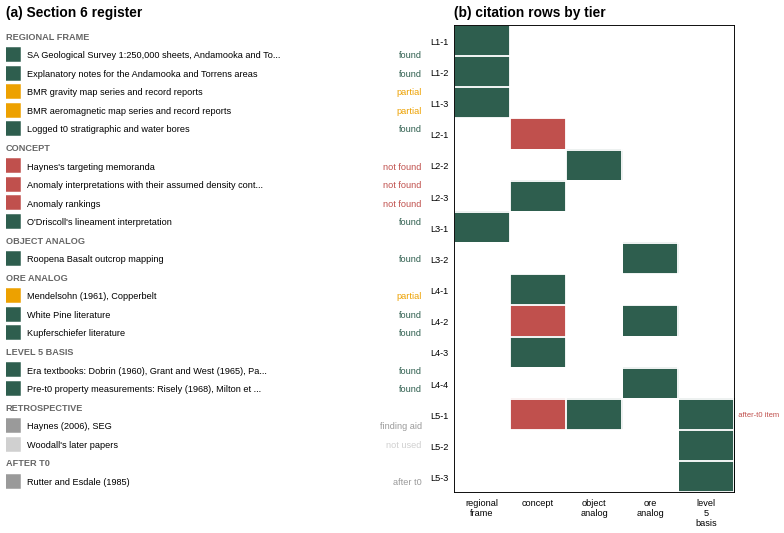

register: 18 items; found 9, partial 3, not found 3, finding aid 1, not used 1, after t0 1
paths present: 17 of 17; items dated after t0 outside finding aids: 0
citation rows naming a retrospective account: none
citation rows naming an after-t0 item: {'L5-1': [1985]}
rows whose annex-named source is not found: ['L2-1', 'L4-1', 'L4-2', 'L5-1']


In [18]:
DB = pd.read_csv(PM / "01_citation_table/wp4_annexA_documentary_basis.csv").fillna("")
T0_YEAR = 1975
DB["path_ok"] = [bool(pth) and (PM / pth).exists() for pth in DB.path]
DB["latest_year"] = [max([int(y) for y in str(v).split(";") if y.strip()], default=np.nan) for v in DB.years]
DB["date_ok"] = (DB.latest_year <= T0_YEAR) | DB.status.isin(["finding aid", "after t0", "not used"]) | DB.latest_year.isna()
# the citation table itself: after-t0 years and retrospective accounts named in the in-state sources
after_t0 = {rid: sorted({int(y) for y in re.findall(r"\b(19[0-9]{2}|20[0-2][0-9])\b", CT.loc[rid, "in_state_source_and_date"]) if int(y) > T0_YEAR})
            for rid in CT.index}
after_t0 = {k: v for k, v in after_t0.items() if v}
RETRO = ["Haynes 2006", "Haynes (2006)", "Woodall"]
retro_hits = {rid: [n for n in RETRO if n in CT.loc[rid, "in_state_source_and_date"]] for rid in CT.index}
retro_hits = {k: v for k, v in retro_hits.items() if v}
# row by tier coverage from the register
TIERS = ["regional frame", "concept", "object analog", "ore analog", "level 5 basis"]
RANK = {"found": 3, "partial": 2, "not found": 1}
COV = pd.DataFrame(0, index=CT.index, columns=TIERS)
for _, d in DB[DB.tier.isin(TIERS)].iterrows():
    for rid in [x for x in d.rows.split(";") if x in CT.index]:
        COV.loc[rid, d.tier] = max(COV.loc[rid, d.tier], RANK.get(d.status, 0))
SCOL = {"found": "#2e5e4e", "partial": "#eda100", "not found": "#c0504d", "finding aid": "#9a9a9a", "after t0": "#9a9a9a", "not used": "#d0d0d0"}
fig, axes = plt.subplots(1, 2, figsize=(COL2, 5.0), gridspec_kw={"width_ratios": [1.5, 1]})
fig.subplots_adjust(left=0.01, right=0.93, top=0.93, bottom=0.08, wspace=0.08)
ax = axes[0]; ax.set_xlim(0, 1); ax.axis("off")
prev, i = None, -1
for _, d in DB.iterrows():
    if d.tier != prev:
        i += 1; ax.text(0.0, i + 0.42, d.tier.upper(), fontsize=FS_ANNOT - 1, color="0.4", fontweight="bold", va="center"); prev = d.tier
    i += 1
    ax.add_patch(plt.Rectangle((0.0, i + 0.05), 0.035, 0.7, color=SCOL[d.status]))
    txt = d.annex_item if len(d.annex_item) < 58 else d.annex_item[:55] + "..."
    ax.text(0.05, i + 0.42, txt, fontsize=FS_ANNOT - 1, va="center")
    ax.text(0.99, i + 0.42, d.status + ("" if d.date_ok else "  date!") + ("" if d.path_ok or not d.path else "  path!"),
            fontsize=FS_ANNOT - 1, va="center", ha="right", color=SCOL[d.status])
ax.set_ylim(i + 1, -0.2)
ax = axes[1]
cmap = plt.matplotlib.colors.ListedColormap(["white", SCOL["not found"], SCOL["partial"], SCOL["found"]])
ax.imshow(COV.values, cmap=cmap, vmin=-0.5, vmax=3.5, aspect="auto")
ax.set_xticks(range(len(TIERS))); ax.set_xticklabels([t.replace(" ", "\n") for t in TIERS], fontsize=FS_ANNOT - 1)
ax.set_yticks(range(len(COV))); ax.set_yticklabels(COV.index, fontsize=FS_ANNOT - 1)
ax.set_xticks(np.arange(-0.5, len(TIERS)), minor=True); ax.set_yticks(np.arange(-0.5, len(COV)), minor=True)
ax.grid(which="minor", color="white", lw=1.2); ax.tick_params(which="both", length=0)
for rid in after_t0: ax.text(len(TIERS) - 0.5, list(COV.index).index(rid), "  after-t0 item", fontsize=FS_ANNOT - 2, va="center", color="#c0504d")
panel_labels(axes, ("(a) Section 6 register", "(b) citation rows by tier"))
fig.savefig(FIG / "wp4_PP_11_documentary_basis.png", dpi=300)
plt.show()
print(f"register: {len(DB)} items; " + ", ".join(f"{k} {v}" for k, v in DB.status.value_counts().items()))
print(f"paths present: {int(DB.path_ok.sum())} of {int((DB.path != '').sum())}; items dated after t0 outside finding aids: {int((~DB.date_ok).sum())}")
print("citation rows naming a retrospective account:", retro_hits or "none")
print("citation rows naming an after-t0 item:", after_t0)
nf = DB[(DB.status == "not found") & (DB.rows != "")]
print("rows whose annex-named source is not found:", sorted({r for x in nf.rows for r in x.split(";")}))


### How to read this figure

(a) The register by tier: green found, amber partial, red not found, grey finding aid or after t0. (b) Which tiers each citation row rests on, coloured by the best status in that tier. All 17 paths exist and nothing after t0 is used outside the labelled items. No row names Haynes 2006 or Woodall. One row names an after-t0 item: L5-1 lists Rutter and Esdale 1985 as a cross-check. Four rows lean on a concept source that was not found (L2-1, L4-1, L4-2 on Haynes's memoranda, L5-1 on WMC's model sheets); each also has a found stand-in except L2-1, which is a declared assumption.


## Section 7. Outputs and interfaces

The deliverable ensemble, the class-agnostic interface, local refinement and the versioned record. **These cells are not executed in the saved notebook; run them locally.** `N_DELIV = 1000` takes about 5 minutes (about 0.3 s per realization); Section 7 allows up to 10,000.


### Step 15. The branch as data

The sampler is a branch definition, `BRANCH_SH`: a draw function, the four geometry stages, a property stage and a summary. `realize_branch(branch, seed)` runs any branch; the Ni-Cu, iron-body, VMS and IOCG branches plug in with their own definitions. The check reruns the 50 realizations of Step 6 through the interface and compares them with the frozen table `wp4_prior_draws_n50_reference_v1.csv`.


In [ ]:
import hashlib
REF = pd.read_csv(TAB / "wp4_prior_draws_n50_reference_v1.csv")
NEW = pd.DataFrame([realize_branch(BRANCH_SH, s)[0] for s in range(1000, 1050)])[REF.columns]
vol_hash = lambda s: hashlib.sha256(np.ascontiguousarray(realize(s, keep_volume=True)[1]["rho"]).tobytes()).hexdigest()[:16]
print("branch:", BRANCH_SH["name"]); print("  geometry family:", BRANCH_SH["geometry_family"])
print("  mineralization rule:", BRANCH_SH["mineralization_rule"])
print("  stages:", [f.__name__ for f in BRANCH_SH["stages"]], "+", BRANCH_SH["properties"].__name__)
print(f"interface check: 50 realizations through realize_branch() against the reference table, max abs difference {np.nanmax(abs(NEW.values - REF.values)):.1e}")
print(f"seed convention: default_rng(seed); seed 11 volume hash {vol_hash(11)} and again {vol_hash(11)}")


### Reading the output

The difference should be of order 1e-13 (rounding) and the two volume hashes identical: the seed alone reproduces a realization, volumes included.


### Step 16. The deliverable ensemble and its likelihood weights

`N_DELIV` realizations, each forward-modelled and weighted by a Gaussian likelihood against the t0 surveys, with the station noise (1.0 mGal) and the declared 5 nT, and an unknown regional plane removed from the misfit. Volumes are not stored: a seed regenerates them. Written: `wp4_prior_ensemble_n1000.csv` (seed, draws, summaries, log-likelihoods, weights) and the volumes of the top-weighted realization in `ensemble/`.


In [ ]:
import time
N_DELIV = 1000          # Section 7 asks for 1,000 to 10,000; about 0.3 s per realization (1,000 in about 5 min)
def loglik(x, y, obs, syn, sd):
    """Gaussian log-likelihood of the data given a realization, with an unknown regional plane removed from the misfit"""
    A = np.c_[np.ones_like(x), (x - X0) / 1e3, (y - Y0) / 1e3]; d = obs - syn
    res = d - A @ np.linalg.lstsq(A, d, rcond=None)[0]
    return -0.5 * np.sum((res / sd) ** 2), res
t0 = time.time(); rows = []
for s in range(SEED0, SEED0 + N_DELIV):
    o, mp, g, t, gs, ms = synthetic(s, rng_noise=False)
    lg, _ = loglik(GXo, GYo, G_OBS, gs, G_SD); lm, _ = loglik(MXo, MYo, M_OBS, ms, RULE["mag_noise_nt"])
    rows.append({**o, "loglik_grav": lg, "loglik_mag": lm})
ENS = pd.DataFrame(rows)
def weights(ll):
    w = np.exp(ll - ll.max()); return w / w.sum()
for tag, ll in [("grav", ENS.loglik_grav), ("mag", ENS.loglik_mag), ("joint", ENS.loglik_grav + ENS.loglik_mag)]:
    ENS["w_" + tag] = weights(ll.values)
ESS = {tag: 1.0 / np.sum(ENS["w_" + tag] ** 2) for tag in ("grav", "mag", "joint")}
ENS.to_csv(TAB / "wp4_prior_ensemble_n1000.csv", index=False)
TOP = int(ENS.loc[ENS.w_joint.idxmax(), "seed"])
o, mp, _, _ = realize(TOP, keep_volume=True)
(TAB / "ensemble").mkdir(exist_ok=True)
np.savez_compressed(TAB / "ensemble" / f"wp4_prior_seed{TOP}_volumes.npz", lith=mp["lith"], rho=mp["rho"], k=mp["k"], res=mp["res"],
                    x=XC, y=YC, z=ZC, seed=TOP)
_, _, _, _, gs_top, ms_top = synthetic(TOP, rng_noise=False)
_, res_top = loglik(GXo, GYo, G_OBS, gs_top, G_SD)
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.5))
fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.2, wspace=0.42)
ax = axes[0]; ax.scatter(ENS.loglik_grav - ENS.loglik_grav.max(), ENS.loglik_mag - ENS.loglik_mag.max(), s=4, color="#2e5e4e", alpha=0.6)
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_xlabel("Gravity log-lik. less best"); ax.set_ylabel("Magnetic log-lik. less best")
ax = axes[1]; ws = np.sort(ENS.w_joint.values)[::-1]
ax.plot(np.arange(1, 21), np.cumsum(ws[:20]), "o-", color="#c0504d", ms=3, lw=1)
ax.set_xlabel("Top-k realizations"); ax.set_ylabel("Cumulative weight"); ax.set_ylim(0, 1.05)
ax = axes[2]; ax.scatter(detrend(GXo, GYo, G_OBS), detrend(GXo, GYo, gs_top), s=5, color="#2a78d6")
lim = [-15, 15]; ax.plot(lim, lim, color="0.5", lw=0.6, ls=":"); ax.set_xlim(lim); ax.set_ylim(-5, 5)
ax.set_xlabel("Observed residual (mGal)"); ax.set_ylabel(f"Seed {TOP} residual (mGal)")
panel_labels(axes, ("(a)", "(b)", "(c)"))
fig.savefig(FIG / "wp4_PP_12_ensemble_weights.png", dpi=300)
plt.show()
per_real = sum(mp[k].nbytes for k in ("lith", "rho", "k", "res"))
print(f"{N_DELIV} realizations (seeds {SEED0}-{SEED0 + N_DELIV - 1}) forward-modelled and weighted in {time.time() - t0:.0f} s")
print(f"effective sample size: gravity {ESS['grav']:.2f}, magnetics {ESS['mag']:.2f}, joint {ESS['joint']:.2f} of {N_DELIV}")
print(f"top-weighted realization: seed {TOP}, joint weight {ENS.w_joint.max():.3f}; its volumes saved to ensemble/wp4_prior_seed{TOP}_volumes.npz")
print(f"gravity misfit sd for seed {TOP}: {res_top.std():.2f} mGal against a noise sd of {np.median(G_SD):.2f}")
print(f"full volumes would take {per_real / 1e6:.1f} MB per realization, {per_real * 1e4 / 1e9:.0f} GB for 10,000; stored instead: seeds, draws, summaries, log-likelihoods")


### How to read this figure

(a) Gravity against magnetic log-likelihood, relative to the best. (b) Cumulative weight of the top 20 realizations. (c) Observed gravity residual against the top-weighted realization at the 342 stations; the dotted line is 1:1. What to expect: the Section 4 mismatch means the weights collapse onto one realization (a 20-member smoke test gave an effective sample size of 1.0), and (c) stays flat. This is the weighting step telling you the same thing as the gate; how to handle it (model error, tempering, a likelihood on summary statistics) belongs to WP3.


### Step 17. Local refinement around a ranked anomaly

The observed gravity anomalies of Step 8 are ranked by peak. `refine(seed, x, y)` regenerates the same realization on a 250 m grid in a 20 km box: surfaces interpolated, basalt ellipses and ore disks redrawn exactly from their stored centres and sizes.


In [ ]:
# rank the observed gravity anomalies of Step 8 by peak; refine one realization around the first
labG, nG = ndimage.label(ANOM_G, structure=np.ones((3, 3)))
RANKED = pd.DataFrame([dict(anomaly=i, peak_mgal=np.nanmax(np.where(labG == i, GRID_G, np.nan)),
                            x=GX[labG == i][np.nanargmax(GRID_G[labG == i])], y=GY[labG == i][np.nanargmax(GRID_G[labG == i])],
                            area_km2=int((labG == i).sum())) for i in range(1, nG + 1)]).sort_values("peak_mgal", ascending=False)
RANKED["rank"] = np.arange(1, len(RANKED) + 1)

def refine(seed, x0, y0, half_km=10.0, dxf=250.0):
    """the same realization on a local grid of dxf cells: surfaces interpolated, objects and ore disks re-drawn exactly"""
    out, maps, objs, ores = realize(seed)
    xf = np.arange(x0 - half_km * 1e3 + dxf / 2, x0 + half_km * 1e3, dxf); yf = np.arange(y0 - half_km * 1e3 + dxf / 2, y0 + half_km * 1e3, dxf)
    GXf, GYf = np.meshgrid(xf, yf); pts = np.c_[GYf.ravel(), GXf.ravel()]
    S = {k: RegularGridInterpolator((YC, XC), maps[k], bounds_error=False, fill_value=None)(pts).reshape(GXf.shape)
         for k in ("s1", "s2", "s3", "cover", "base")}
    near = lambda a: a[np.clip(np.searchsorted(YC, GYf) - 1, 0, NY - 1), np.clip(np.searchsorted(XC, GXf) - 1, 0, NX - 1)]
    btop = np.full(GXf.shape, np.nan); a = np.radians(FIX["basalt_az"])
    for _, ob in objs.iterrows():
        u = (GXf - ob.x) / 1e3 * np.sin(a) + (GYf - ob.y) / 1e3 * np.cos(a); v = (GXf - ob.x) / 1e3 * np.cos(a) - (GYf - ob.y) / 1e3 * np.sin(a)
        m = (u / (ob.length_km / 2)) ** 2 + (v / (ob.length_km / 2 / FIX["basalt_aspect"])) ** 2 <= 1
        btop = np.where(m, np.maximum(S["base"] - ob.thickness_m, S["cover"]), btop)
    ore = np.zeros(GXf.shape, bool)
    for _, e in ores.iterrows(): ore |= (GXf - e.x) ** 2 + (GYf - e.y) ** 2 <= (e.diam_km * 1e3 / 2) ** 2
    z = ZC[None, None, :]; lith = np.full(GXf.shape + (len(ZC),), 7, np.int8)
    for code, surf in [(1, S["s1"]), (2, S["s2"]), (3, S["s3"]), (4, S["cover"]), (5, S["base"])]:
        lith[(lith == 7) & (z < surf[:, :, None])] = code
    lith[(z >= btop[:, :, None]) & (z < S["base"][:, :, None]) & np.isfinite(btop)[:, :, None]] = 6
    return dict(x=xf, y=yf, lith=lith, ore=ore, reduced=near(maps["reduced"]), contact=np.where(np.isfinite(btop), btop, S["base"]))

A1 = RANKED.iloc[0]
FINE = refine(TOP, A1.x, A1.y)
_, mcoarse, _, _ = realize(TOP, keep_volume=True)
jy_c = int(np.argmin(abs(YC - A1.y))); jy_f = int(np.argmin(abs(FINE["y"] - A1.y)))
ixc = (XC >= A1.x - 10e3) & (XC <= A1.x + 10e3)
lcmap = plt.matplotlib.colors.ListedColormap([UNIT_COL[c] for c in range(1, 8)])
zb = np.r_[0, np.cumsum(HZ)]
fig, axes = plt.subplots(2, 1, figsize=(COL15, 3.6), sharex=True)
fig.subplots_adjust(left=0.12, right=0.97, top=0.9, bottom=0.13, hspace=0.3)
xe_c = (np.r_[XC[ixc] - DX / 2, XC[ixc][-1] + DX / 2] - A1.x) / 1e3
axes[0].pcolormesh(xe_c, zb, mcoarse["lith"][jy_c][ixc].T, cmap=lcmap, vmin=0.5, vmax=7.5, shading="flat", rasterized=True)
xe_f = (np.r_[FINE["x"] - 125, FINE["x"][-1] + 125] - A1.x) / 1e3
axes[1].pcolormesh(xe_f, zb, FINE["lith"][jy_f].T, cmap=lcmap, vmin=0.5, vmax=7.5, shading="flat", rasterized=True)
xo = (FINE["x"][FINE["ore"][jy_f]] - A1.x) / 1e3
if len(xo): axes[1].plot(xo, FINE["contact"][jy_f][FINE["ore"][jy_f]], "|", color="#b0302a", ms=6)
for ax in axes: ax.set_ylim(1500, 0); ax.set_xlim(-10, 10); ax.set_ylabel("Depth (m)")
axes[1].set_xlabel(f"Easting from ranked anomaly 1 (km)")
panel_labels(axes, (f"(a) seed {TOP}, regional grid (1 km)", f"(b) same realization refined on demand (250 m)"))
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=UNIT_COL[c], label=LITH[c]) for c in range(1, 8)], loc="upper center", ncol=7,
           fontsize=FS_ANNOT - 2, bbox_to_anchor=(0.54, 1.01), frameon=False, handlelength=0.9, columnspacing=0.6)
fig.savefig(FIG / "wp4_PP_13_local_refinement.png", dpi=300)
plt.show()
print(RANKED.head(5).assign(x=lambda d: ((d.x - ODX) / 1e3).round(1), y=lambda d: ((d.y - ODY) / 1e3).round(1)).rename(
      columns={"x": "east_of_OD_km", "y": "north_of_OD_km"}).round(2).to_string(index=False))
print(f"refined grid {len(FINE['x'])} x {len(FINE['y'])} x {len(ZC)} cells of 250 m; basalt cells {int((FINE['lith'] == 6).sum())}, "
      f"ore footprint {FINE['ore'].sum() * 0.0625:.1f} km2 in the box")


### How to read this figure

(a) The top-weighted realization on the 1 km regional grid, west to east through ranked anomaly 1. (b) The same realization refined to 250 m. Unit boundaries must agree; object edges are sharper in (b). The printed table lists the five highest-ranked observed anomalies.


### Step 18. The versioned record


In [ ]:
import json, datetime
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()[:12]
VERSION = {"prior": "WP4 Annex A, sediment-hosted branch", "version": "0.1", "status": "end-to-end run before rulings",
           "t0": "1975-05-02", "built": str(datetime.date.today()),
           "citation_table_sha": sha(PM / "01_citation_table/wp4_annexA_citation_table_draft.csv"),
           "documentary_basis_sha": sha(PM / "01_citation_table/wp4_annexA_documentary_basis.csv"),
           "sampler_sha": sha(PM / "08_prior_models/wp4_sh_prior_sampler.py"),
           "seed_convention": "numpy default_rng(seed); synthetic noise default_rng(seed + 10,000,000)",
           "seeds": {"figures": [11, 23, 37], "row_check": [1000, 1049], "predictive_check": [SEED0, SEED0 + N_ENS - 1],
                     "deliverable_ensemble": [SEED0, SEED0 + N_DELIV - 1]},
           "section4_rule": RULE, "field_1962": FIELD,
           "section4_gate": GATE.groupby(["field", "status"]).size().unstack(fill_value=0).to_dict(orient="index"),
           "effective_sample_size": {k: round(float(v), 3) for k, v in ESS.items()}, "top_weighted_seed": TOP}
TAG = f"WP4-A-SH v{VERSION['version']} ({VERSION['citation_table_sha']})"
(TAB / "wp4_prior_version.json").write_text(json.dumps(VERSION, indent=2, default=float))
print("prior version tag:", TAG); print(json.dumps(VERSION, indent=2, default=float))


### Reading the output

`wp4_prior_version.json` names the prior (WP4-A-SH v0.1), the hashes of the citation table, the register and the sampler module, the seed conventions, the Section 4 rule and gate, and the effective sample size. Every downstream figure should quote the tag.


## What this shows

An end-to-end run of the annex before any ruling. Sections 2, 3 and 5: the recipe runs from the confirmed table; basalt count, reduced fraction and contrast agree with their rows, and derived tonnage fills the gap between the Gunson and world clusters.

Section 4: a gross mismatch for gravity (amplitude, width and residual sd outside every realization) and a near pass for magnetics. With a uniform 2.60 g/cm3 basement, basalt piles and cover cannot make the observed gravity field.

Section 6: every named source is accounted for; three concept documents are not in open file (Haynes's memoranda, WMC's model sheets, anomaly rankings), and one after-t0 item sits in L5-1 as a cross-check.

Section 7: the interface, seed convention, refinement and version record are in place; the likelihood weights, run locally, are expected to collapse onto one realization because of the Section 4 mismatch.

Rulings to take: the Section 4 change (basement density variation or the basalt thickness cap); fixed settings without rows; tonnage; basalt placement; the likelihood design for WP3; the standing of Haynes 2006 and Rutter and Esdale 1985.
